In [ ]:
import os
# Run from the notebooks/ folder: data are read from ../data, figures are written to ../figures.
DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data"))
FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "figures"))
os.makedirs(FIG_DIR, exist_ok=True)
os.chdir(DATA_DIR)

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np

pd.options.display.max_colwidth = 999
pd.options.display.max_columns = 999

In [2]:
ds = load_dataset("open-llm-leaderboard/contents")
benchmark_df = ds['train'].to_pandas()

In [3]:
benchmark_df.head()

,eval_name,Precision,Type,T,Weight type,Architecture,Model,fullname,Model sha,Average ⬆️,Hub License,Hub ❤️,#Params (B),Available on the hub,MoE,Flagged,Chat Template,CO₂ cost (kg),IFEval Raw,IFEval,BBH Raw,BBH,MATH Lvl 5 Raw,MATH Lvl 5,GPQA Raw,GPQA,MUSR Raw,MUSR,MMLU-PRO Raw,MMLU-PRO,Merged,Official Providers,Upload To Hub Date,Submission Date,Generation,Base Model
0,0-hero_Matter-0.2-7B-DPO_bfloat16,bfloat16,"💬 chat models (RLHF, DPO, IFT, ...)",💬,Original,MistralForCausalLM,"<a target=""_blank"" href=""https://huggingface.co/0-hero/Matter-0.2-7B-DPO"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">0-hero/Matter-0.2-7B-DPO</a> <a target=""_blank"" href=""https://huggingface.co/datasets/open-llm-leaderboard/0-hero__Matter-0.2-7B-DPO-details"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">📑</a>",0-hero/Matter-0.2-7B-DPO,26a66f0d862e2024ce4ad0a09c37052ac36e8af6,8.906361,apache-2.0,3,7.242,True,False,False,True,1.219174,0.330279,33.027921,0.359625,10.055525,0.014350,1.435045,0.259228,1.230425,0.381375,5.871875,0.116356,1.817376,False,False,2024-04-13,2024-08-05,0,0-hero/Matter-0.2-7B-DPO
1,01-ai_Yi-1.5-34B_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.co/01-ai/Yi-1.5-34B"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">01-ai/Yi-1.5-34B</a> <a target=""_blank"" href=""https://huggingface.co/datasets/open-llm-leaderboard/01-ai__Yi-1.5-34B-details"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">📑</a>",01-ai/Yi-1.5-34B,4b486f81c935a2dadde84c6baa1e1370d40a098f,25.646494,apache-2.0,46,34.389,True,False,False,False,22.703398,0.284117,28.411725,0.597639,42.749363,0.153323,15.332326,0.365772,15.436242,0.423604,11.217188,0.466589,40.732122,False,True,2024-05-11,2024-06-12,0,01-ai/Yi-1.5-34B
2,01-ai_Yi-1.5-34B-32K_bfloat16,bfloat16,🟢 pretrained,🟢,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.co/01-ai/Yi-1.5-34B-32K"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">01-ai/Yi-1.5-34B-32K</a> <a target=""_blank"" href=""https://huggingface.co/datasets/open-llm-leaderboard/01-ai__Yi-1.5-34B-32K-details"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">📑</a>",01-ai/Yi-1.5-34B-32K,2c03a29761e4174f20347a60fbe229be4383d48b,26.727913,apache-2.0,36,34.389,True,False,False,False,23.154629,0.311869,31.186917,0.601569,43.381847,0.154079,15.407855,0.363255,15.100671,0.439823,14.077865,0.470911,41.212323,False,True,2024-05-15,2024-06-12,0,01-ai/Yi-1.5-34B-32K
3,01-ai_Yi-1.5-34B-Chat_bfloat16,bfloat16,"💬 chat models (RLHF, DPO, IFT, ...)",💬,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.co/01-ai/Yi-1.5-34B-Chat"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">01-ai/Yi-1.5-34B-Chat</a> <a target=""_blank"" href=""https://huggingface.co/datasets/open-llm-leaderboard/01-ai__Yi-1.5-34B-Chat-details"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">📑</a>",01-ai/Yi-1.5-34B-Chat,f3128b2d02d82989daae566c0a7eadc621ca3254,33.357994,apache-2.0,268,34.389,True,False,False,True,22.423844,0.606676,60.667584,0.608375,44.262826,0.277190,27.719033,0.364933,15.324385,0.428198,13.058073,0.452045,39.116061,False,True,2024-05-10,2024-06-12,0,01-ai/Yi-1.5-34B-Chat
4,01-ai_Yi-1.5-34B-Chat-16K_bfloat16,bfloat16,"💬 chat models (RLHF, DPO, IFT, ...)",💬,Original,LlamaForCausalLM,"<a target=""_blank"" href=""https://huggingface.co/01-ai/Yi-1.5-34B-Chat-16K"" style=""color: var(--link-text-color); text-decoration: underline;text-decoration-style: dotted;"">01-ai/Yi-1.5-34B-Chat-16K</a> <a target=""_blank"" href=""https://huggingface.co/datasets/open-llm-leader

In [4]:
benchmark_df.columns

Index(['eval_name', 'Precision', 'Type', 'T', 'Weight type', 'Architecture',
       'Model', 'fullname', 'Model sha', 'Average ⬆️', 'Hub License', 'Hub ❤️',
       '#Params (B)', 'Available on the hub', 'MoE', 'Flagged',
       'Chat Template', 'CO₂ cost (kg)', 'IFEval Raw', 'IFEval', 'BBH Raw',
       'BBH', 'MATH Lvl 5 Raw', 'MATH Lvl 5', 'GPQA Raw', 'GPQA', 'MUSR Raw',
       'MUSR', 'MMLU-PRO Raw', 'MMLU-PRO', 'Merged', 'Official Providers',
       'Upload To Hub Date', 'Submission Date', 'Generation', 'Base Model'],
      dtype='object')

In [5]:
benchmark_df[(benchmark_df['#Params (B)'] > 6) & (benchmark_df['#Params (B)'] <= 9) & (benchmark_df['Base Model'].str.contains("instruct"))]['Base Model'].unique()

array(['Alibaba-NLP/gte-Qwen2-7B-instruct',
       'BSC-LT/salamandra-7b-instruct (Merge)', 'Deci/DeciLM-7B-instruct',
       'Edgerunners/meta-llama-3-8b-instruct-hf-ortho-baukit-34fail-3000total-bf16',
       'GoToCompany/llama3-8b-cpt-sahabatai-v1-instruct (Merge)',
       'NAPS-ai/naps-llama-3_1-8b-instruct-v0.3',
       'NAPS-ai/naps-llama-3_1-8b-instruct-v0.4 (Merge)',
       'NAPS-ai/naps-llama-3_1-instruct-v0.5.0',
       'NAPS-ai/naps-llama-3_1_instruct-v0.6.0 (Merge)',
       'llm-jp/llm-jp-3-7.2b-instruct3',
       'Sakalti/llama-3-yanyuedao-8b-instruct (Merge)',
       'ehristoforu/mllama-3.1-8b-instruct (Merge)',
       'ibm-granite/granite-3.0-8b-instruct (Merge)',
       'ibm-granite/granite-3.1-8b-instruct (Merge)',
       'ibm-granite/granite-3.2-8b-instruct (Merge)',
       'lodrick-the-lafted/llama-3.1-8b-instruct-ortho-v7',
       'microsoft/Phi-3-small-128k-instruct',
       'microsoft/Phi-3-small-8k-instruct',
       'mkxu/llama-3-8b-instruct-fpo',
       'neopoli

In [6]:
all_models = ["meta-llama/Meta-Llama-3-8B-Instruct", "meta-llama/Llama-3.2-3B-Instruct", "mistralai/Mistral-7B-Instruct-v0.2", "Qwen/Qwen2.5-7B-Instruct", "tiiuae/falcon-7b-instruct", \
                             "Qwen/Qwen2.5-14B-Instruct", "Qwen/Qwen2.5-1.5B-Instruct", "Qwen/Qwen2.5-0.5B-Instruct", "Qwen/Qwen2.5-3B-Instruct", 'microsoft/Phi-3-mini-4k-instruct', 'microsoft/Phi-3-small-8k-instruct']

benchmark_df = benchmark_df[benchmark_df.fullname.str.contains("|".join(all_models))]

In [7]:
benchmark_df = benchmark_df.groupby(['fullname'])[['IFEval','BBH','MMLU-PRO']].max().reset_index(drop=False)

In [8]:
benchmark_df = benchmark_df[benchmark_df.fullname != 'Qwen/Qwen2.5-14B-Instruct-1M'].reset_index(drop=True)
benchmark_df = benchmark_df[benchmark_df.fullname != 'Qwen/Qwen2.5-7B-Instruct-1M'].reset_index(drop=True)
benchmark_df = benchmark_df[benchmark_df.fullname != 'tiiuae/falcon-7b-instruct'].reset_index(drop=True)
benchmark_df = benchmark_df[benchmark_df.fullname.str.contains("Phi") == False].reset_index(drop=True)

In [9]:
benchmark_df

,fullname,IFEval,BBH,MMLU-PRO
0,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346
1,Qwen/Qwen2.5-1.5B-Instruct,44.755693,19.809786,19.991135
2,Qwen/Qwen2.5-14B-Instruct,81.577769,48.360707,43.382462
3,Qwen/Qwen2.5-3B-Instruct,64.749199,25.801394,25.051714
4,Qwen/Qwen2.5-7B-Instruct,75.852516,34.892117,36.521129
5,meta-llama/Llama-3.2-3B-Instruct,73.931613,24.059186,24.386820
6,meta-llama/Meta-Llama-3-8B-Instruct,74.083986,28.244950,29.604388
7,mistralai/Mistral-7B-Instruct-v0.2,54.962278,22.910602,19.076906


In [10]:
#benchmark_df[['fullname','IFEval','MMLU-PRO','BBH']].to_csv("benchmark.csv", index=False)

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ======== Config ========
CSV_PATH = "benchmark.csv"  # path to your benchmark data
OUT_PNG = os.path.join(FIG_DIR, "stacked_barplot_horizontal_annotated.png")
OUT_SVG = os.path.join(FIG_DIR, "stacked_barplot_horizontal_annotated.svg")

# ======== Nature-like Style ========
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ======== Load & Process Data ========
df = pd.read_csv(CSV_PATH)

def find_col(df, candidates):
    """Find the first matching column name among candidates."""
    cols = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        for k, v in cols.items():
            if cand.lower().replace("_", "") in k.replace("_", ""):
                return v
    raise KeyError(f"No column for {candidates}")

model_col = find_col(df, ["model", "name", "model_name"])

# Detect benchmark columns
task_candidates = [["mmlu", "mmlu_pro"], ["ifeval"], ["bbh"]]
task_cols = []
for cand in task_candidates:
    try:
        task_cols.append(find_col(df, cand))
    except Exception:
        pass

task_cols = ['MMLU-PRO', 'BBH', 'IFEval']

df = df[[model_col] + task_cols].dropna()
df['total'] = df[task_cols].values.sum(1)
df = df.sort_values(by='total', ascending=True) #df.sort_values(by=task_cols[0], ascending=True)

# ======== Plot ========
fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(df))
colors = plt.cm.tab20c(np.linspace(0.1, 0.6, len(task_cols)))

# Horizontal stacked bar with annotation
for i, task in enumerate(task_cols):
    vals = df[task].values
    bars = ax.barh(df[model_col], vals, left=bottom, label=task.upper(),
                   color=colors[i], edgecolor='k', linewidth=0.4)
    
    # Add text labels on each segment
    for bar, value in zip(bars, vals):
        if value > 0.01:  # skip too small bars
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}",
                ha="center", va="center", fontsize=12, color="black"
            )
    bottom += vals

ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_title("Model performance across existing benchmarks")
ax.legend(loc="lower right", frameon=False, fontsize=15)
#ax.grid(axis="x", color="#eaeaea", linestyle="--", linewidth=0.6)

# Clean aesthetics
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_SVG, bbox_inches="tight")
plt.close(fig)

print(f"Saved annotated plots:\n{OUT_PNG}\n{OUT_SVG}")


Saved annotated plots:
stacked_barplot_horizontal_annotated.png
stacked_barplot_horizontal_annotated.svg


In [12]:
'''
import os, re, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt

CSV_PATH = "benchmark.csv"  # set to your path if different
OUT_PNG  = os.path.join(FIG_DIR, "mmlu_vs_ifeval_scatter.png")
OUT_SVG  = os.path.join(FIG_DIR, "mmlu_vs_ifeval_scatter2.svg")
OUT_TOP  = "discrepant_pairs.csv"

# Nature-like aesthetic
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 0.8,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "pdf.fonttype": 42,  # editable text in vector exports
    "ps.fonttype": 42,
})

def find_col(df, candidates):
    """Find the first matching column name among candidates (robust to spacing/underscore/case)."""
    cols = {c.lower().strip(): c for c in df.columns}
    norm = lambda s: s.lower().replace("_", "").replace(" ", "")
    for cand in candidates:
        lc = cand.lower().strip()
        if lc in cols:
            return cols[lc]
        for k, v in cols.items():
            if norm(lc) == norm(k):
                return v
    # fuzzy contains
    for k, v in cols.items():
        for cand in candidates:
            if norm(cand) in norm(k):
                return v
    raise KeyError(f"None of {candidates} in columns: {list(df.columns)}")

def parse_params_from_name(name):
    """Try to extract param size like '7B', '14B', '3.1B' from model name."""
    if not isinstance(name, str):
        return np.nan
    m = re.search(r'(\d+(\.\d+)?)\s*[bB]\b', name)
    return float(m.group(1)) if m else np.nan

def scale_sizes(x, base=25.0, min_size=30.0, max_size=400.0):
    """Linear scale of marker sizes with clipping."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 0.05, None)
    s = base * x
    return np.clip(s, min_size, max_size)

def choose_discrepant_pairs(df, xcol, ycol, namecol):
    """
    Find top 2 pairs (i,j) with x_i > x_j and y_i < y_j.
    Score D = (x_i - x_j) + (y_j - y_i), i.e., how much they disagree across the two benchmarks.
    """
    arr = df[[xcol, ycol, namecol]].to_numpy()
    pairs = []
    n = len(arr)
    for i in range(n):
        for j in range(n):
            if i == j: 
                continue
            xi, yi, ni = arr[i]
            xj, yj, nj = arr[j]
            try:
                xi, yi, xj, yj = float(xi), float(yi), float(xj), float(yj)
            except Exception:
                continue
            if xi > xj and yi < yj:
                D = (xi - xj) + (yj - yi)
                pairs.append((D, i, j))
    pairs.sort(reverse=True, key=lambda t: t[0])
    chosen, seen = [], set()
    for D, i, j in pairs:
        key = tuple(sorted([i, j]))
        if key in seen:
            continue
        chosen.append((D, i, j))
        seen.add(key)
        if len(chosen) >= 2:
            break
    return chosen

# ---- Load data ----
df = pd.read_csv(CSV_PATH)

model_col = find_col(df, ["model", "model_id", "model_name", "name", "fullname"])
mmlu_col  = find_col(df, ["mmlu_pro", "mmlu-pro", "mmlu pro", "mmlu_pro_score", "mmlupro", "MMLU-PRO"])
ifev_col  = find_col(df, ["ifeval", "ifeval_score", "if_eval", "if-eval", "if eval", "IFEval"])

# parameter size (billions): look for a numeric column; else parse from model name; else median
param_candidates = ["params_b", "params_billion", "param_b", "n_params_b", "parameters_b", "n_params_billion"]
try:
    param_col = find_col(df, param_candidates)
    params_b = pd.to_numeric(df[param_col], errors="coerce")
except KeyError:
    params_b = df[model_col].map(parse_params_from_name)

df[mmlu_col] = pd.to_numeric(df[mmlu_col], errors="coerce")
df[ifev_col] = pd.to_numeric(df[ifev_col], errors="coerce")
df["params_billion"] = params_b
if df["params_billion"].dropna().empty:
    df["params_billion"] = 7.0  # default if nothing found
else:
    df["params_billion"] = df["params_billion"].fillna(df["params_billion"].median())

df = df.dropna(subset=[mmlu_col, ifev_col, model_col]).copy()

df.loc[df.fullname == 'Phi-mini', "params_billion"] = 3.8
df.loc[df.fullname == 'Phi-small', "params_billion"] = 7

sizes = scale_sizes(df["params_billion"].values, base=30)
colors = ["orange"] * 5 + ["skyblue"] * 2 + ["gray"]*2 + ["purple"]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6.0, 5.0))
sc = ax.scatter(df[mmlu_col], df[ifev_col], s=sizes, alpha=0.85, edgecolor="k", linewidth=0.4, color=colors)

ax.set_xlabel("MMLU-Pro score")
ax.set_ylabel("IFEval score")
ax.set_title("Extrinsic benchmarks disagree across models\n(marker size ∝ parameters in billions)")

# minimalist polish
ax.grid(True, which="major", axis="both", color="#eaeaea")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

# annotate each point
for x, y, label in zip(df[mmlu_col], df[ifev_col], df[model_col]):
    ax.text(x, y, str(label), fontsize=8, ha="center", va="center", clip_on=True)

# highlight top 2 discrepant pairs with arrows + note
pairs = choose_discrepant_pairs(df, mmlu_col, ifev_col, model_col)
coords = list(zip(df[mmlu_col].values, df[ifev_col].values, df[model_col].values))

for (D, i, j) in pairs:
    xi, yi, ni = coords[i]
    xj, yj, nj = coords[j]
    ax.annotate("", xy=(xj, yj), xytext=(xi, yi),
                arrowprops=dict(arrowstyle="->", lw=1.2, shrinkA=6, shrinkB=6))
    xm, ym = (xi + xj) / 2.0, (yi + yj) / 2.0
    ax.text(xm, ym, f"{ni} higher MMLU-Pro\n{nj} higher IFEval",
            fontsize=8, ha="center", va="bottom",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", lw=0.8))

fig.tight_layout()
fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_SVG, bbox_inches="tight")
plt.close(fig)

# export discrepant pairs table
rows_out = []
for (D, i, j) in pairs:
    rows_out.append({
        "discrepancy_score": D,
        "model_high_MMLU_low_IF": df.iloc[i][model_col],
        "MMLU_high": float(df.iloc[i][mmlu_col]),
        "IFEval_low": float(df.iloc[i][ifev_col]),
        "model_low_MMLU_high_IF": df.iloc[j][model_col],
        "MMLU_low": float(df.iloc[j][mmlu_col]),
        "IFEval_high": float(df.iloc[j][ifev_col]),
        "params_b_model_i": float(df.iloc[i]["params_billion"]),
        "params_b_model_j": float(df.iloc[j]["params_billion"]),
    })
pd.DataFrame(rows_out).to_csv(OUT_TOP, index=False)

print(f"Saved: {OUT_PNG}\nSaved: {OUT_SVG}\nPairs: {OUT_TOP}")
'''

'\nimport os, re, numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt\n\nCSV_PATH = "benchmark.csv"  # set to your path if different\nOUT_PNG  = "mmlu_vs_ifeval_scatter.png"\nOUT_SVG  = "mmlu_vs_ifeval_scatter2.svg"\nOUT_TOP  = "discrepant_pairs.csv"\n\n# Nature-like aesthetic\nmpl.rcParams.update({\n    "figure.dpi": 300,\n    "savefig.dpi": 300,\n    "font.family": "serif",\n    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],\n    "axes.linewidth": 0.8,\n    "axes.titlesize": 12,\n    "axes.labelsize": 11,\n    "xtick.labelsize": 10,\n    "ytick.labelsize": 10,\n    "legend.fontsize": 10,\n    "pdf.fonttype": 42,  # editable text in vector exports\n    "ps.fonttype": 42,\n})\n\ndef find_col(df, candidates):\n    """Find the first matching column name among candidates (robust to spacing/underscore/case)."""\n    cols = {c.lower().strip(): c for c in df.columns}\n    norm = lambda s: s.lower().replace("_", "").replace(" ", "")\n    for cand in candidates:

In [13]:
lpp_df = pd.read_csv("LPP.csv").dropna(subset=['effective_rank']).reset_index(drop=True)
lpp_df = lpp_df[lpp_df.prefix_tokens > 10].reset_index(drop=True)

In [14]:
lpp_df.head()

,prefix_tokens,mean_next_token_entropy,silhouette_score,model_id,participation_ratio,effective_rank
0,20,0.033815,NaN,microsoft/Phi-3-small-8k-instruct,0.009405,0.011682
1,30,0.174921,NaN,microsoft/Phi-3-small-8k-instruct,0.007851,0.014983
2,40,0.088867,NaN,microsoft/Phi-3-small-8k-instruct,0.007737,0.021680
3,50,0.095177,NaN,microsoft/Phi-3-small-8k-instruct,0.009868,0.036310
4,60,0.089425,NaN,microsoft/Phi-3-small-8k-instruct,0.012021,0.052132


In [15]:
lpp_df_ = lpp_df.groupby(['model_id'])[['mean_next_token_entropy','participation_ratio','effective_rank']].agg(['min','max','mean'])
lpp_df_ = lpp_df_.reset_index(drop=False)
lpp_df_.columns = [i[0]+"_"+ str(i[1]) for i in lpp_df_.columns]

lpp_df_

,model_id_,mean_next_token_entropy_min,mean_next_token_entropy_max,mean_next_token_entropy_mean,participation_ratio_min,participation_ratio_max,participation_ratio_mean,effective_rank_min,effective_rank_max,effective_rank_mean
0,Qwen/Qwen2.5-0.5B-Instruct,0.115086,0.220743,0.154024,0.011798,0.031864,0.022436,0.018652,0.135234,0.089889
1,Qwen/Qwen2.5-1.5B-Instruct,0.093120,0.191280,0.125428,0.007134,0.013899,0.011162,0.011849,0.082870,0.056579
2,Qwen/Qwen2.5-14B-Instruct,0.019099,0.177340,0.106832,0.003689,0.007315,0.004455,0.010552,0.023769,0.017999
3,Qwen/Qwen2.5-3B-Instruct,0.056345,0.159431,0.113601,0.005684,0.009691,0.007867,0.010229,0.064886,0.043623
4,Qwen/Qwen2.5-7B-Instruct,0.087032,0.166075,0.113909,0.005484,0.007716,0.006953,0.010736,0.043613,0.032333
5,meta-llama/Llama-3.2-3B-Instruct,0.079830,0.179076,0.125702,0.005912,0.032475,0.020287,0.009199,0.181351,0.108232
6,meta-llama/Meta-Llama-3-8B-Instruct,0.054458,0.147321,0.092300,0.006385,0.023997,0.015685,0.009202,0.122512,0.073987
7,microsoft/Phi-3-mini-4k-instruct,0.092121,0.183721,0.124439,0.006633,0.010886,0.009654,0.010414,0.133401,0.072912
8,microsoft/Phi-3-small-8k-instruct,0.033815,0.174921,0.104975,0.007737,0.025727,0.016783,0.011682,0.145488,0.082900
9,mistralai/Mistral-7B-Instruct-v0.2,0.043618,0.186277,0.096328,0.004985,0.020603,0.011786,0.009902,0.130520,0.066051


In [16]:
benchmark_df1 = pd.merge(benchmark_df, lpp_df, left_on=['fullname'], right_on=['model_id'], how='inner')


In [17]:
benchmark_df1.head()

,fullname,IFEval,BBH,MMLU-PRO,prefix_tokens,mean_next_token_entropy,silhouette_score,model_id,participation_ratio,effective_rank
0,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,20,0.196229,NaN,Qwen/Qwen2.5-0.5B-Instruct,0.012957,0.018652
1,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,30,0.220743,NaN,Qwen/Qwen2.5-0.5B-Instruct,0.011798,0.027934
2,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,40,0.122030,NaN,Qwen/Qwen2.5-0.5B-Instruct,0.012940,0.042120
3,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,50,0.143528,NaN,Qwen/Qwen2.5-0.5B-Instruct,0.015092,0.056804
4,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,60,0.137985,NaN,Qwen/Qwen2.5-0.5B-Instruct,0.017517,0.071102


In [18]:
benchmark_df1 = benchmark_df1[benchmark_df1.prefix_tokens > 10].reset_index(drop=True)

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

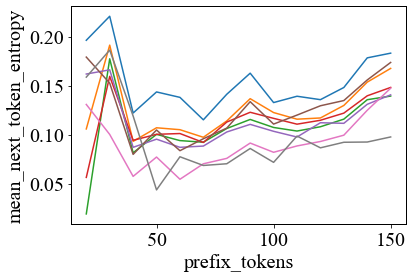

In [20]:
sns.lineplot(data=benchmark_df1, x='prefix_tokens', y='mean_next_token_entropy', hue='fullname', legend=False)
plt.show()

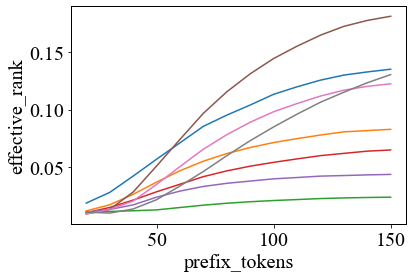

In [21]:
sns.lineplot(data=benchmark_df1, x='prefix_tokens', y='effective_rank', hue='fullname', legend=False)
plt.show()

In [22]:
lpp_df2 = lpp_df.pivot_table(index=['model_id'], columns=['prefix_tokens'], values=['mean_next_token_entropy', 'participation_ratio', 'effective_rank']).reset_index(drop=False)


In [23]:
lpp_df2.columns = [i[0]+"_"+ str(i[1]) for i in lpp_df2.columns]

In [24]:
lpp_df2

,model_id_,effective_rank_20,effective_rank_30,effective_rank_40,effective_rank_50,effective_rank_60,effective_rank_70,effective_rank_80,effective_rank_90,effective_rank_100,effective_rank_110,effective_rank_120,effective_rank_130,effective_rank_140,effective_rank_150,mean_next_token_entropy_20,mean_next_token_entropy_30,mean_next_token_entropy_40,mean_next_token_entropy_50,mean_next_token_entropy_60,mean_next_token_entropy_70,mean_next_token_entropy_80,mean_next_token_entropy_90,mean_next_token_entropy_100,mean_next_token_entropy_110,mean_next_token_entropy_120,mean_next_token_entropy_130,mean_next_token_entropy_140,mean_next_token_entropy_150,participation_ratio_20,participation_ratio_30,participation_ratio_40,participation_ratio_50,participation_ratio_60,participation_ratio_70,participation_ratio_80,participation_ratio_90,participation_ratio_100,participation_ratio_110,participation_ratio_120,participation_ratio_130,participation_ratio_140,participation_ratio_150
0,Qwen/Qwen2.5-0.5B-Instruct,0.018652,0.027934,0.042120,0.056804,0.071102,0.085473,0.095222,0.104026,0.113367,0.119882,0.125697,0.130092,0.132839,0.135234,0.196229,0.220743,0.122030,0.143528,0.137985,0.115086,0.141160,0.162660,0.132687,0.139136,0.135652,0.148057,0.178295,0.183085,0.012957,0.011798,0.012940,0.015092,0.017517,0.020269,0.022183,0.024114,0.026310,0.027979,0.029430,0.030461,0.031188,0.031864
1,Qwen/Qwen2.5-1.5B-Instruct,0.011849,0.017153,0.026253,0.036878,0.046797,0.055105,0.061761,0.067020,0.071355,0.074736,0.077898,0.080652,0.081775,0.082870,0.105789,0.191280,0.093120,0.106966,0.105012,0.097272,0.113912,0.136644,0.122484,0.115733,0.116973,0.129746,0.153525,0.167530,0.007600,0.007134,0.007629,0.008668,0.009827,0.010825,0.011605,0.012214,0.012742,0.013147,0.013473,0.013706,0.013797,0.013899
2,Qwen/Qwen2.5-14B-Instruct,0.010552,0.011339,0.011950,0.012698,0.014773,0.016816,0.018503,0.019816,0.020861,0.021701,0.022566,0.023131,0.023514,0.023769,0.019099,0.177340,0.081459,0.100278,0.093898,0.092236,0.106244,0.115471,0.107277,0.103640,0.108016,0.115778,0.135612,0.139305,0.007315,0.005252,0.004154,0.003689,0.003803,0.003962,0.004088,0.004177,0.004236,0.004283,0.004346,0.004353,0.004360,0.004357
3,Qwen/Qwen2.5-3B-Instruct,0.010229,0.014821,0.021238,0.028443,0.035048,0.041655,0.046680,0.050773,0.054108,0.057110,0.059953,0.061920,0.063859,0.064886,0.056345,0.159431,0.094209,0.100302,0.101092,0.091970,0.112801,0.122784,0.116587,0.110652,0.114621,0.121911,0.139581,0.148120,0.006451,0.005730,0.005684,0.006278,0.006839,0.007475,0.007936,0.008324,0.008612,0.008938,0.009212,0.009373,0.009593,0.009691
4,Qwen/Qwen2.5-7B-Instruct,0.010736,0.013062,0.017081,0.023763,0.029075,0.033117,0.035844,0.037808,0.039750,0.040890,0.042117,0.042621,0.043190,0.043613,0.161788,0.166075,0.087032,0.095336,0.087032,0.088320,0.102675,0.110449,0.103376,0.097534,0.112113,0.111511,0.130932,0.140559,0.007716,0.005898,0.005484,0.006297,0.006887,0.007103,0.007187,0.007216,0.007251,0.007245,0.007286,0.007234,0.007264,0.007276
5,meta-llama/Llama-3.2-3B-Instruct,0.009199,0.013142,0.028230,0.050860,0.074084,0.096817,0.115529,0.131186,0.144525,0.155245,0.164845,0.172529,0.177703,0.181351,0.179076,0.152492,0.079830,0.104681,0.083598,0.095784,0.106622,0.133588,0.110735,0.119903,0.129420,0.134744,0.155734,0.173620,0.006804,0.005912,0.007948,0.010942,0.014113,0.017419,0.020393,0.023056,0.025459,0.027532,0.029350,0.030812,0.031800,0.032475
6,meta-llama/Meta-Llama-3-8B-Instruct,0.009202,0.013083,0.020430,0.034850,0.050385,0.065551,0.078207,0.089045,0.098168,0.105303,0.111821,0.116963,0.120297,0.122512,0.130760,0.100163,0.057390,0.077117,0.054458,0.070235,0.075758,0.091383,0.081961,0.088437,0.092982,0.099411,0.124822,0.147321,0.006902,0.006385,0.006716,0.008902,0.011237,0.013564,0.015668,0.017611,0.019312,0.020711,0.021996,0.022984,0.023605,0.023997
7,microsoft/Phi-3-mini-4k-instruct,0.011241,0.010414,0.016921,0.026454,0.041728,0.057169,0.071970,0.083977,0.096604,0.106293,0.114802,0.121526,0.128268,0.133401

In [25]:
#lpp_df2 = lpp_df.groupby(['model_id'])[['mean_next_token_entropy', 'silhouette_score', 'participation_ratio', 'effective_rank', 'mean_abs_offdiag']].max().reset_index(drop=False)


In [26]:
#benchmark_df = ds['train'].to_pandas()
#benchmark_df = pd.merge(benchmark_df[['fullname','IFEval','BBH','GPQA','MUSR','MMLU-PRO']], lpp_df2, left_on=['fullname'], right_on=['model_id_'], how='inner').drop_duplicates(subset=['fullname']).reset_index(drop=True)
benchmark_df = pd.merge(benchmark_df, lpp_df2, left_on=['fullname'], right_on=['model_id_'], how='inner').drop_duplicates(subset=['fullname']).reset_index(drop=True)



In [28]:
benchmark_df

,fullname,IFEval,BBH,MMLU-PRO,model_id_,effective_rank_20,effective_rank_30,effective_rank_40,effective_rank_50,effective_rank_60,effective_rank_70,effective_rank_80,effective_rank_90,effective_rank_100,effective_rank_110,effective_rank_120,effective_rank_130,effective_rank_140,effective_rank_150,mean_next_token_entropy_20,mean_next_token_entropy_30,mean_next_token_entropy_40,mean_next_token_entropy_50,mean_next_token_entropy_60,mean_next_token_entropy_70,mean_next_token_entropy_80,mean_next_token_entropy_90,mean_next_token_entropy_100,mean_next_token_entropy_110,mean_next_token_entropy_120,mean_next_token_entropy_130,mean_next_token_entropy_140,mean_next_token_entropy_150,participation_ratio_20,participation_ratio_30,participation_ratio_40,participation_ratio_50,participation_ratio_60,participation_ratio_70,participation_ratio_80,participation_ratio_90,participation_ratio_100,participation_ratio_110,participation_ratio_120,participation_ratio_130,participation_ratio_140,participation_ratio_150
0,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,Qwen/Qwen2.5-0.5B-Instruct,0.018652,0.027934,0.042120,0.056804,0.071102,0.085473,0.095222,0.104026,0.113367,0.119882,0.125697,0.130092,0.132839,0.135234,0.196229,0.220743,0.122030,0.143528,0.137985,0.115086,0.141160,0.162660,0.132687,0.139136,0.135652,0.148057,0.178295,0.183085,0.012957,0.011798,0.012940,0.015092,0.017517,0.020269,0.022183,0.024114,0.026310,0.027979,0.029430,0.030461,0.031188,0.031864
1,Qwen/Qwen2.5-1.5B-Instruct,44.755693,19.809786,19.991135,Qwen/Qwen2.5-1.5B-Instruct,0.011849,0.017153,0.026253,0.036878,0.046797,0.055105,0.061761,0.067020,0.071355,0.074736,0.077898,0.080652,0.081775,0.082870,0.105789,0.191280,0.093120,0.106966,0.105012,0.097272,0.113912,0.136644,0.122484,0.115733,0.116973,0.129746,0.153525,0.167530,0.007600,0.007134,0.007629,0.008668,0.009827,0.010825,0.011605,0.012214,0.012742,0.013147,0.013473,0.013706,0.013797,0.013899
2,Qwen/Qwen2.5-14B-Instruct,81.577769,48.360707,43.382462,Qwen/Qwen2.5-14B-Instruct,0.010552,0.011339,0.011950,0.012698,0.014773,0.016816,0.018503,0.019816,0.020861,0.021701,0.022566,0.023131,0.023514,0.023769,0.019099,0.177340,0.081459,0.100278,0.093898,0.092236,0.106244,0.115471,0.107277,0.103640,0.108016,0.115778,0.135612,0.139305,0.007315,0.005252,0.004154,0.003689,0.003803,0.003962,0.004088,0.004177,0.004236,0.004283,0.004346,0.004353,0.004360,0.004357
3,Qwen/Qwen2.5-3B-Instruct,64.749199,25.801394,25.051714,Qwen/Qwen2.5-3B-Instruct,0.010229,0.014821,0.021238,0.028443,0.035048,0.041655,0.046680,0.050773,0.054108,0.057110,0.059953,0.061920,0.063859,0.064886,0.056345,0.159431,0.094209,0.100302,0.101092,0.091970,0.112801,0.122784,0.116587,0.110652,0.114621,0.121911,0.139581,0.148120,0.006451,0.005730,0.005684,0.006278,0.006839,0.007475,0.007936,0.008324,0.008612,0.008938,0.009212,0.009373,0.009593,0.009691
4,Qwen/Qwen2.5-7B-Instruct,75.852516,34.892117,36.521129,Qwen/Qwen2.5-7B-Instruct,0.010736,0.013062,0.017081,0.023763,0.029075,0.033117,0.035844,0.037808,0.039750,0.040890,0.042117,0.042621,0.043190,0.043613,0.161788,0.166075,0.087032,0.095336,0.087032,0.088320,0.102675,0.110449,0.103376,0.097534,0.112113,0.111511,0.130932,0.140559,0.007716,0.005898,0.005484,0.006297,0.006887,0.007103,0.007187,0.007216,0.007251,0.007245,0.007286,0.007234,0.007264,0.007276
5,meta-llama/Llama-3.2-3B-Instruct,73.931613,24.059186,24.386820,meta-llama/Llama-3.2-3B-Instruct,0.009199,0.013142,0.028230,0.050860,0.074084,0.096817,0.115529,0.131186,0.144525,0.155245,0.164845,0.172529,0.177703,0.181351,0.179076,0.152492,0.079830,0.104681,0.083598,0.095784,0.106622,0.133588,0.110735,0.119903,0.129420,0.134744,0.155734,0.173620,0.006804,0.005912,0.007948,0.010942,0.014113,0.017419,0.020393,0.023056,0.025459,0.027532,0.029350,0.030812,0.031800,0.032475
6,meta-llama/Meta-Llama-3-8B-Instruct,74.083986,28.244950,29.604388,meta-llama/Meta-Llama-3-8B-Instruct,0.009202,0.013083,0.020430,0.034850,0.050385,0.065551,0.078207,0.089045,0.098168,0.105303,0.111821,0.1

In [27]:
#benchmark_df = benchmark_df[benchmark_df.fullname.str.contains("falcon") == False].reset_index(drop=True)

In [28]:
benchmark_df.to_csv("hypo.csv", index=False)


In [29]:
#!python lpp_analyze.py --csv hypo.csv --outdir ./results/
#!python lpp_analyze.py --csv hypo.csv --out_dir results


In [30]:
benchmark_df.head()

,fullname,IFEval,BBH,MMLU-PRO,model_id_,effective_rank_20,effective_rank_30,effective_rank_40,effective_rank_50,effective_rank_60,effective_rank_70,effective_rank_80,effective_rank_90,effective_rank_100,effective_rank_110,effective_rank_120,effective_rank_130,effective_rank_140,effective_rank_150,mean_next_token_entropy_20,mean_next_token_entropy_30,mean_next_token_entropy_40,mean_next_token_entropy_50,mean_next_token_entropy_60,mean_next_token_entropy_70,mean_next_token_entropy_80,mean_next_token_entropy_90,mean_next_token_entropy_100,mean_next_token_entropy_110,mean_next_token_entropy_120,mean_next_token_entropy_130,mean_next_token_entropy_140,mean_next_token_entropy_150,participation_ratio_20,participation_ratio_30,participation_ratio_40,participation_ratio_50,participation_ratio_60,participation_ratio_70,participation_ratio_80,participation_ratio_90,participation_ratio_100,participation_ratio_110,participation_ratio_120,participation_ratio_130,participation_ratio_140,participation_ratio_150
0,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,Qwen/Qwen2.5-0.5B-Instruct,0.018652,0.027934,0.042120,0.056804,0.071102,0.085473,0.095222,0.104026,0.113367,0.119882,0.125697,0.130092,0.132839,0.135234,0.196229,0.220743,0.122030,0.143528,0.137985,0.115086,0.141160,0.162660,0.132687,0.139136,0.135652,0.148057,0.178295,0.183085,0.012957,0.011798,0.012940,0.015092,0.017517,0.020269,0.022183,0.024114,0.026310,0.027979,0.029430,0.030461,0.031188,0.031864
1,Qwen/Qwen2.5-1.5B-Instruct,44.755693,19.809786,19.991135,Qwen/Qwen2.5-1.5B-Instruct,0.011849,0.017153,0.026253,0.036878,0.046797,0.055105,0.061761,0.067020,0.071355,0.074736,0.077898,0.080652,0.081775,0.082870,0.105789,0.191280,0.093120,0.106966,0.105012,0.097272,0.113912,0.136644,0.122484,0.115733,0.116973,0.129746,0.153525,0.167530,0.007600,0.007134,0.007629,0.008668,0.009827,0.010825,0.011605,0.012214,0.012742,0.013147,0.013473,0.013706,0.013797,0.013899
2,Qwen/Qwen2.5-14B-Instruct,81.577769,48.360707,43.382462,Qwen/Qwen2.5-14B-Instruct,0.010552,0.011339,0.011950,0.012698,0.014773,0.016816,0.018503,0.019816,0.020861,0.021701,0.022566,0.023131,0.023514,0.023769,0.019099,0.177340,0.081459,0.100278,0.093898,0.092236,0.106244,0.115471,0.107277,0.103640,0.108016,0.115778,0.135612,0.139305,0.007315,0.005252,0.004154,0.003689,0.003803,0.003962,0.004088,0.004177,0.004236,0.004283,0.004346,0.004353,0.004360,0.004357
3,Qwen/Qwen2.5-3B-Instruct,64.749199,25.801394,25.051714,Qwen/Qwen2.5-3B-Instruct,0.010229,0.014821,0.021238,0.028443,0.035048,0.041655,0.046680,0.050773,0.054108,0.057110,0.059953,0.061920,0.063859,0.064886,0.056345,0.159431,0.094209,0.100302,0.101092,0.091970,0.112801,0.122784,0.116587,0.110652,0.114621,0.121911,0.139581,0.148120,0.006451,0.005730,0.005684,0.006278,0.006839,0.007475,0.007936,0.008324,0.008612,0.008938,0.009212,0.009373,0.009593,0.009691
4,Qwen/Qwen2.5-7B-Instruct,75.852516,34.892117,36.521129,Qwen/Qwen2.5-7B-Instruct,0.010736,0.013062,0.017081,0.023763,0.029075,0.033117,0.035844,0.037808,0.039750,0.040890,0.042117,0.042621,0.043190,0.043613,0.161788,0.166075,0.087032,0.095336,0.087032,0.088320,0.102675,0.110449,0.103376,0.097534,0.112113,0.111511,0.130932,0.140559,0.007716,0.005898,0.005484,0.006297,0.006887,0.007103,0.007187,0.007216,0.007251,0.007245,0.007286,0.007234,0.007264,0.007276


In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [30]:
def calculate_effective_rank_slope(x):
    
    l = x[[col for col in benchmark_df.columns if "effective_rank" in col]].values

    mm = MinMaxScaler()
    #l = mm.fit_transform(l.reshape(-1,1))[:,0]
    
    model = LinearRegression()
    model.fit(np.arange(1, len(l)+1).reshape(-1, 1), l)

    # The slope is the coefficient
    slope_lr = model.coef_[0]

    return slope_lr

def calculate_mean_next_token_entropy_slope(x):
    
    l = x[[col for col in benchmark_df.columns if "mean_next_token_entropy" in col]].values

    mm = MinMaxScaler()
    #l = mm.fit_transform(l.reshape(-1,1))[:,0]
    
    model = LinearRegression()
    model.fit(np.arange(1, len(l)+1).reshape(-1, 1), l)

    # The slope is the coefficient
    slope_lr = model.coef_[0]

    return slope_lr

def calculate_participation_ratio_slope(x):
    
    l = x[[col for col in benchmark_df.columns if "participation_ratio" in col]].values

    mm = MinMaxScaler()
    #l = mm.fit_transform(l.reshape(-1,1))[:,0]
    
    model = LinearRegression()
    model.fit(np.arange(1, len(l)+1).reshape(-1, 1), l)

    # The slope is the coefficient
    slope_lr = model.coef_[0]

    return slope_lr

In [31]:
benchmark_df['effective_rank_slope'] = benchmark_df.apply(calculate_effective_rank_slope, axis=1)
benchmark_df['mean_next_token_entropy_slope'] = benchmark_df.apply(calculate_mean_next_token_entropy_slope, axis=1)
benchmark_df['participation_ratio_slope'] = benchmark_df.apply(calculate_participation_ratio_slope, axis=1)

In [32]:
benchmark_df = benchmark_df[['fullname','IFEval','BBH','MMLU-PRO','effective_rank_slope','mean_next_token_entropy_slope', \
'participation_ratio_slope']]

In [33]:
benchmark_df = pd.merge(benchmark_df, lpp_df_, left_on=['fullname'], right_on=['model_id_']).drop(['model_id_'], axis=1)

In [34]:
benchmark_df

,fullname,IFEval,BBH,MMLU-PRO,effective_rank_slope,mean_next_token_entropy_slope,participation_ratio_slope,mean_next_token_entropy_min,mean_next_token_entropy_max,mean_next_token_entropy_mean,participation_ratio_min,participation_ratio_max,participation_ratio_mean,effective_rank_min,effective_rank_max,effective_rank_mean
0,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,0.009406,-0.000832,0.001735,0.115086,0.220743,0.154024,0.011798,0.031864,0.022436,0.018652,0.135234,0.089889
1,Qwen/Qwen2.5-1.5B-Instruct,44.755693,19.809786,19.991135,0.005724,0.002064,0.000586,0.093120,0.191280,0.125428,0.007134,0.013899,0.011162,0.011849,0.082870,0.056579
2,Qwen/Qwen2.5-14B-Instruct,81.577769,48.360707,43.382462,0.001151,0.003450,-0.000085,0.019099,0.177340,0.106832,0.003689,0.007315,0.004455,0.010552,0.023769,0.017999
3,Qwen/Qwen2.5-3B-Instruct,64.749199,25.801394,25.051714,0.004370,0.003200,0.000336,0.056345,0.159431,0.113601,0.005684,0.009691,0.007867,0.010229,0.064886,0.043623
4,Qwen/Qwen2.5-7B-Instruct,75.852516,34.892117,36.521129,0.002633,-0.000482,0.000075,0.087032,0.166075,0.113909,0.005484,0.007716,0.006953,0.010736,0.043613,0.032333
5,meta-llama/Llama-3.2-3B-Instruct,73.931613,24.059186,24.386820,0.014746,0.001946,0.002301,0.079830,0.179076,0.125702,0.005912,0.032475,0.020287,0.009199,0.181351,0.108232
6,meta-llama/Meta-Llama-3-8B-Instruct,74.083986,28.244950,29.604388,0.009765,0.002630,0.001574,0.054458,0.147321,0.092300,0.006385,0.023997,0.015685,0.009202,0.122512,0.073987
7,mistralai/Mistral-7B-Instruct-v0.2,54.962278,22.910602,19.076906,0.010455,-0.003596,0.001219,0.043618,0.186277,0.096328,0.004985,0.020603,0.011786,0.009902,0.130520,0.066051


In [37]:
benchmark_df[['fullname','participation_ratio_slope','mean_next_token_entropy_mean']].to_csv("lpp_scores.csv", index=False)

In [38]:
extrinsic_tasks = ['IFEval','BBH','MMLU-PRO']
intrinsic_tasks = benchmark_df.columns[4:].to_list() #['efficient_rank_slope','mean_next_token_entropy_slope', 'participation_ratio_slope']

In [39]:
intrinsic_tasks

['effective_rank_slope',
 'mean_next_token_entropy_slope',
 'participation_ratio_slope',
 'mean_next_token_entropy_min',
 'mean_next_token_entropy_max',
 'mean_next_token_entropy_mean',
 'participation_ratio_min',
 'participation_ratio_max',
 'participation_ratio_mean',
 'effective_rank_min',
 'effective_rank_max',
 'effective_rank_mean']

In [40]:
intrinsic_tasks = [
 'mean_next_token_entropy_min',
 'effective_rank_max',
 'participation_ratio_max']

In [41]:
intrinsic_tasks

['mean_next_token_entropy_min',
 'effective_rank_max',
 'participation_ratio_max']

In [42]:
import scipy.stats

In [43]:
lpp1_res = pd.DataFrame()
i = 0
for col1 in extrinsic_tasks:
    for col2 in intrinsic_tasks:
        test = scipy.stats.pearsonr(benchmark_df[col1], benchmark_df[col2])
        lpp1_res.loc[i, "intrinsic"] = col2
        lpp1_res.loc[i, "extrinsic"] = col1
        lpp1_res.loc[i, "correlation"] = test.statistic
        lpp1_res.loc[i, "pvalue"] = test.pvalue

        i += 1
        
        if test.pvalue <= 0.05:
            print (col1, col2, test)

    print ("===============================")

BBH mean_next_token_entropy_min PearsonRResult(statistic=-0.7531253031757476, pvalue=0.030994854645756815)


In [44]:
benchmark_df.columns

Index(['fullname', 'IFEval', 'BBH', 'MMLU-PRO', 'effective_rank_slope',
       'mean_next_token_entropy_slope', 'participation_ratio_slope',
       'mean_next_token_entropy_min', 'mean_next_token_entropy_max',
       'mean_next_token_entropy_mean', 'participation_ratio_min',
       'participation_ratio_max', 'participation_ratio_mean',
       'effective_rank_min', 'effective_rank_max', 'effective_rank_mean'],
      dtype='object')

In [45]:
lpp1_res

,intrinsic,extrinsic,correlation,pvalue
0,mean_next_token_entropy_min,IFEval,-0.648297,0.082089
1,effective_rank_max,IFEval,-0.324058,0.433589
2,participation_ratio_max,IFEval,-0.396184,0.331226
3,mean_next_token_entropy_min,BBH,-0.753125,0.030995
4,effective_rank_max,BBH,-0.672950,0.067406
5,participation_ratio_max,BBH,-0.680664,0.063158
6,mean_next_token_entropy_min,MMLU-PRO,-0.650653,0.080613
7,effective_rank_max,MMLU-PRO,-0.658952,0.075535
8,participation_ratio_max,MMLU-PRO,-0.669387,0.069424


In [46]:
lpp1_res.to_csv("lpp1_res.csv", index=False)

In [4]:
#!/usr/bin/env python3
"""
High-quality heatmap from a precomputed correlations file (with p-values).

Input:
  /mnt/data/lpp1_res.csv  (must contain correlation values AND p-values)

Outputs:
  /mnt/data/corr_heatmap.png
  /mnt/data/corr_heatmap.svg
  /mnt/data/corr_matrix_used.csv
  /mnt/data/pval_matrix_used.csv
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

IN_PATH  = "lpp1_res.csv"
OUT_PNG  = os.path.join(FIG_DIR, "corr_heatmap.png")
OUT_SVG  = os.path.join(FIG_DIR, "corr_heatmap.svg")
OUT_CORR = "corr_matrix_used.csv"
OUT_PVAL = "pval_matrix_used.csv"

# Nature-like minimal style (Matplotlib only; default colormap)
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 0.8,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

def detect_long_form(df: pd.DataFrame):
    """Detect long/tidy form with two label columns + r + p columns."""
    cols = list(df.columns)
    ncols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    scols = [c for c in cols if not pd.api.types.is_numeric_dtype(df[c])]
    r_cands = [c for c in ncols if any(k in norm(c) for k in ["r","rho","pearson","corr","correlation"])]
    p_cands = [c for c in ncols if any(k in norm(c) for k in ["p","pvalue","pval","p_value"])]
    if r_cands and p_cands and len(scols) >= 2:
        # Prefer exact names if present
        def pick(cands, keys):
            exact = [c for c in cands if norm(c) in keys]
            return exact[0] if exact else cands[0]
        r_col = pick(r_cands, {"r","pearson","pearsonr","corr","correlation"})
        p_col = pick(p_cands, {"p","pvalue","pval","p_value"})

        row_pref = {"intrinsic","source","row","x","intrinsicmetric","in_metric","in"}
        col_pref = {"extrinsic","target","col","y","extrinsicmetric","out_metric","out"}
        def best_label(cands, pref):
            for c in cands:
                if norm(c) in pref:
                    return c
            return cands[0]
        row_label = best_label(scols, row_pref)
        col_label = best_label([c for c in scols if c != row_label], col_pref)
        return True, (row_label, col_label, r_col, p_col)
    return False, None

def long_to_mats(df: pd.DataFrame, row_label, col_label, r_col, p_col):
    corr = df.pivot(index=row_label, columns=col_label, values=r_col)
    pval = df.pivot(index=row_label, columns=col_label, values=p_col)
    corr = corr.sort_index().sort_index(axis=1)
    pval = pval.reindex_like(corr)
    return corr, pval

def detect_wide_form(df: pd.DataFrame):
    """
    Detect wide matrices:
      - First column = row index (labels)
      - Correlation columns (numeric) without 'p' in name
      - P-value columns (numeric) with 'p'/'pval'/'pvalue' in name, aligned to corr by name
    """
    cols = list(df.columns)
    idx_col = None
    if not pd.api.types.is_numeric_dtype(df[cols[0]]):
        idx_col = cols[0]
        df_w = df.set_index(idx_col).copy()
    else:
        df_w = df.copy()

    corr_cols = [c for c in df_w.columns
                 if pd.api.types.is_numeric_dtype(df_w[c])
                 and not any(k in norm(c) for k in ["p","pval","pvalue","p_value"])]

    pval_cols = [c for c in df_w.columns
                 if pd.api.types.is_numeric_dtype(df_w[c])
                 and any(k in norm(c) for k in ["p","pval","pvalue","p_value"])]

    def clean_name(c):
        nc = norm(c)
        for lead in ["pvalue", "pval", "p_", "p"]:
            if nc.startswith(norm(lead)):
                nc = nc[len(norm(lead)):]
        return nc

    if corr_cols and pval_cols:
        corr_map = {norm(c): c for c in corr_cols}
        pmap = {clean_name(c): c for c in pval_cols}
        common = [k for k in corr_map.keys() if k in pmap]
        if common:
            corr = df_w[[corr_map[k] for k in common]].copy()
            pval = df_w[[pmap[k] for k in common]].copy()
            pval.columns = corr.columns  # align names
            return True, (idx_col, corr, pval)
    return False, None

def add_sigstars(p):
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return ""

# --- Load CSV ---
if not os.path.exists(IN_PATH):
    raise FileNotFoundError(f"Could not find {IN_PATH}")
df = pd.read_csv(IN_PATH)

# --- Build correlation and p-value matrices ---
is_long, long_info = detect_long_form(df)
if is_long:
    row_label, col_label, r_col, p_col = long_info
    corr, pval = long_to_mats(df, row_label, col_label, r_col, p_col)
else:
    is_wide, wide_info = detect_wide_form(df)
    if is_wide:
        idx_col, corr, pval = wide_info
    else:
        raise ValueError(
            "Could not infer layout. Expect either long form ([row, col, r, p]) "
            "or wide form with correlation columns and matching p-value columns."
        )

# Save matrices actually used
corr.to_csv(OUT_CORR)
pval.to_csv(OUT_PVAL)

# --- Plot heatmap (Pearson r with significance stars) ---
rows = list(corr.index)
cols = list(corr.columns)
mat  = corr.values
pmat = pval.values

fig_w = max(5, len(cols) * 0.85)
fig_h = max(4, len(rows) * 0.55)
fig, ax = plt.subplots(figsize=(fig_w*2, fig_h*1.5))

im = ax.imshow(mat, aspect='auto', cmap="twilight", vmin=-1, vmax=1)  # default colormap (per your plotting rule)

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(rows)))
ax.set_xticklabels(cols, rotation=0)
ax.set_yticklabels(rows, rotation=90, va='center')

# Annotate each cell: r + significance stars by p-value
for i in range(len(rows)):
    for j in range(len(cols)):
        r = mat[i, j]
        p = pmat[i, j] if not pd.isna(pmat[i, j]) else 1.0
        ax.text(j, i, f"{r:.2f}{add_sigstars(p)}",
                ha="center", va="center", fontsize=15, color="black")

ax.set_xlabel("")
ax.set_ylabel("LPP metrics")
ax.set_title("Correlation with significance\n(* p<0.05, ** p<0.01, *** p<0.001)")

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("", rotation=0, labelpad=12)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_SVG, bbox_inches="tight")
plt.close(fig)

print("Saved:")
print("  Figure (PNG):", OUT_PNG)
print("  Figure (SVG):", OUT_SVG)
print("  Corr matrix  :", OUT_CORR)
print("  P-val matrix :", OUT_PVAL)


Saved:
  Figure (PNG): corr_heatmap.png
  Figure (SVG): corr_heatmap.svg
  Corr matrix  : corr_matrix_used.csv
  P-val matrix : pval_matrix_used.csv


In [48]:
lpp2_res = pd.DataFrame()
i = 0

for col1 in extrinsic_tasks:
    for col2 in intrinsic_tasks:
        benchmark_df_ = benchmark_df[benchmark_df.fullname.str.contains("Qwen")]
        test = scipy.stats.pearsonr(benchmark_df_[col1], benchmark_df_[col2])
        lpp2_res.loc[i, "intrinsic"] = col2
        lpp2_res.loc[i, "extrinsic"] = col1
        lpp2_res.loc[i, "correlation"] = test.statistic
        lpp2_res.loc[i, "pvalue"] = test.pvalue
        
        if test.pvalue <= 0.05:
            print (col1, col2, test)

    print ("===============================")

IFEval effective_rank_max PearsonRResult(statistic=-0.9698867826914883, pvalue=0.006244506479732729)
IFEval participation_ratio_max PearsonRResult(statistic=-0.8895579441046123, pvalue=0.04332184282299332)
BBH effective_rank_max PearsonRResult(statistic=-0.9658823426814639, pvalue=0.007526057595218949)
MMLU-PRO effective_rank_max PearsonRResult(statistic=-0.981945918598009, pvalue=0.0029041385415742777)


In [49]:
#lpp2_res.to_csv("lpp2_res.csv", index=False)

In [50]:
#dfs.to_csv("ar.csv", index=False)

In [35]:
dummy_tasks1 = pd.read_csv("spc.csv")
dummy_tasks1.columns = ['fullname','spc_em','spc_f1']

dummy_tasks2 = pd.read_csv("ar.csv")
dummy_tasks2.columns = ['fullname','ar_acc','ar_overconf','ar_underconf']

In [36]:
benchmark_df = pd.merge(benchmark_df, dummy_tasks1, how='left')
benchmark_df = pd.merge(benchmark_df, dummy_tasks2, how='left')

In [37]:
benchmark_df = benchmark_df.dropna().reset_index(drop=True)

In [38]:
benchmark_df

,fullname,IFEval,BBH,MMLU-PRO,effective_rank_slope,mean_next_token_entropy_slope,participation_ratio_slope,mean_next_token_entropy_min,mean_next_token_entropy_max,mean_next_token_entropy_mean,participation_ratio_min,participation_ratio_max,participation_ratio_mean,effective_rank_min,effective_rank_max,effective_rank_mean,spc_em,spc_f1,ar_acc,ar_overconf,ar_underconf
0,Qwen/Qwen2.5-0.5B-Instruct,31.529121,8.434864,7.995346,0.009406,-0.000832,0.001735,0.115086,0.220743,0.154024,0.011798,0.031864,0.022436,0.018652,0.135234,0.089889,0.14,0.702048,0.48,0.00,0.0
1,Qwen/Qwen2.5-1.5B-Instruct,44.755693,19.809786,19.991135,0.005724,0.002064,0.000586,0.093120,0.191280,0.125428,0.007134,0.013899,0.011162,0.011849,0.082870,0.056579,0.22,0.750969,0.52,0.00,0.0
2,Qwen/Qwen2.5-14B-Instruct,81.577769,48.360707,43.382462,0.001151,0.003450,-0.000085,0.019099,0.177340,0.106832,0.003689,0.007315,0.004455,0.010552,0.023769,0.017999,0.30,0.780208,0.76,0.22,0.0
3,Qwen/Qwen2.5-3B-Instruct,64.749199,25.801394,25.051714,0.004370,0.003200,0.000336,0.056345,0.159431,0.113601,0.005684,0.009691,0.007867,0.010229,0.064886,0.043623,0.31,0.779782,0.60,0.00,0.0
4,Qwen/Qwen2.5-7B-Instruct,75.852516,34.892117,36.521129,0.002633,-0.000482,0.000075,0.087032,0.166075,0.113909,0.005484,0.007716,0.006953,0.010736,0.043613,0.032333,0.56,0.841574,0.62,0.00,0.0
5,meta-llama/Llama-3.2-3B-Instruct,73.931613,24.059186,24.386820,0.014746,0.001946,0.002301,0.079830,0.179076,0.125702,0.005912,0.032475,0.020287,0.009199,0.181351,0.108232,0.27,0.737619,0.48,0.66,0.0
6,meta-llama/Meta-Llama-3-8B-Instruct,74.083986,28.244950,29.604388,0.009765,0.002630,0.001574,0.054458,0.147321,0.092300,0.006385,0.023997,0.015685,0.009202,0.122512,0.073987,0.31,0.693714,0.71,0.00,0.0
7,mistralai/Mistral-7B-Instruct-v0.2,54.962278,22.910602,19.076906,0.010455,-0.003596,0.001219,0.043618,0.186277,0.096328,0.004985,0.020603,0.011786,0.009902,0.130520,0.066051,0.28,0.745238,0.91,0.00,0.0


In [39]:
benchmark_df.to_csv("final_data.csv", index=False)

In [41]:
benchmark_df.to_csv("plot_data2.csv", index=False)

In [55]:
#benchmark_df[['fullname','spc_f1','ar_acc']].to_csv("lpp_new_scores.csv", index=False)

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ======== Config ========
CSV_PATH = "lpp_new_scores.csv"  # path to your benchmark data
OUT_PNG = os.path.join(FIG_DIR, "stacked_barplot_horizontal_annotated2.png")
OUT_SVG = os.path.join(FIG_DIR, "stacked_barplot_horizontal_annotated2.svg")

# ======== Nature-like Style ========
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ======== Load & Process Data ========
df = pd.read_csv(CSV_PATH)

def find_col(df, candidates):
    """Find the first matching column name among candidates."""
    cols = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        for k, v in cols.items():
            if cand.lower().replace("_", "") in k.replace("_", ""):
                return v
    raise KeyError(f"No column for {candidates}")

model_col = find_col(df, ["model", "name", "model_name"])

# Detect benchmark columns
task_candidates = [["SPC"], ["AR"]]
task_cols = []
for cand in task_candidates:
    try:
        task_cols.append(find_col(df, cand))
    except Exception:
        pass

task_cols = ['SPC', 'AR']

df = df[[model_col] + task_cols].dropna()
df['total'] = df[task_cols].values.sum(1)
df = df.sort_values(by='total', ascending=True) #df.sort_values(by=task_cols[0], ascending=True)

# ======== Plot ========
fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(df))
colors = plt.cm.tab20c(np.linspace(0.1, 0.6, len(task_cols)))

# Horizontal stacked bar with annotation
for i, task in enumerate(task_cols):
    vals = df[task].values
    bars = ax.barh(df[model_col], vals, left=bottom, label=task.upper(),
                   color=colors[i], edgecolor='k', linewidth=0.4)
    
    # Add text labels on each segment
    for bar, value in zip(bars, vals):
        if value > 0.01:  # skip too small bars
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                ha="center", va="center", fontsize=12, color="black"
            )
    bottom += vals

ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_title("Model performance across new benchmarks")
ax.legend(loc="lower right", frameon=False, fontsize=15)
#ax.grid(axis="x", color="#eaeaea", linestyle="--", linewidth=0.6)

# Clean aesthetics
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_SVG, bbox_inches="tight")
plt.close(fig)

print(f"Saved annotated plots:\n{OUT_PNG}\n{OUT_SVG}")


Saved annotated plots:
stacked_barplot_horizontal_annotated2.png
stacked_barplot_horizontal_annotated2.svg


In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ======== Config ========
CSV_PATH = "lpp_lpp_scores.csv"  # path to your benchmark data
OUT_PNG = os.path.join(FIG_DIR, "stacked_barplot_horizontal_annotated3_max.png")
OUT_SVG = os.path.join(FIG_DIR, "stacked_barplot_horizontal_annotated3_max.pdf")

# ======== Nature-like Style ========
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 1,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ======== Load & Process Data ========
df = pd.read_csv(CSV_PATH)

def find_col(df, candidates):
    """Find the first matching column name among candidates."""
    cols = {c.lower().strip(): c for c in df.columns}
    for cand in candidates:
        for k, v in cols.items():
            if cand.lower().replace("_", "") in k.replace("_", ""):
                return v
    raise KeyError(f"No column for {candidates}")

model_col = find_col(df, ["model", "name", "model_name"])

# Detect benchmark columns
task_candidates = [["Entropy"], ["PR"], ["ER"]]
task_cols = []
for cand in task_candidates:
    try:
        task_cols.append(find_col(df, cand))
    except Exception:
        pass

task_cols = ['Entropy','PR','ER']

df = df[[model_col] + task_cols].dropna()
df['total'] = df[task_cols].values.sum(1)

df = df.sort_values(by='total', ascending=True) #df.sort_values(by=task_cols[0], ascending=True)

df2 = pd.DataFrame()
order = ['Qwen-0.5B','Qwen-1.5B','Qwen-3B','Qwen-7B','Qwen-14B','Llama-3B','Llama-8B','Mistral-7B']
order.reverse()
df2['fullname'] = order

df = pd.merge(df, df2, how='right')

# ======== Plot ========
fig, ax = plt.subplots(figsize=(7, 5))
bottom = np.zeros(len(df))
colors = plt.cm.tab20c(np.linspace(0.1, 0.6, len(task_cols)))

# Horizontal stacked bar with annotation
for i, task in enumerate(task_cols):
    vals = df[task].values
    bars = ax.barh(df[model_col], vals, left=bottom, label=task.upper(),
                   color=colors[i], edgecolor='k', linewidth=0.4)
    
    # Add text labels on each segment
    for bar, value in zip(bars, vals):
        if value > 0.01:  # skip too small bars
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.2f}",
                ha="center", va="center", fontsize=12, color="black"
            )
    bottom += vals

ax.set_xlabel("Score")
ax.set_ylabel("")
ax.set_xticklabels([])
ax.set_title("Model performance across LPP metrics")

#ax.legend(loc="lower right", frameon=False, fontsize=15)

#ax.grid(axis="x", color="#eaeaea", linestyle="--", linewidth=0.6)

# Clean aesthetics
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_SVG, bbox_inches="tight", dpi=300)
plt.close(fig)

print(f"Saved annotated plots:\n{OUT_PNG}\n{OUT_SVG}")


Saved annotated plots:
stacked_barplot_horizontal_annotated3_max.png
stacked_barplot_horizontal_annotated3_max.pdf


In [57]:
benchmark_df[['IFEval','BBH','MMLU-PRO']].corr()

,IFEval,BBH,MMLU-PRO
IFEval,1.000000,0.862344,0.903535
BBH,0.862344,1.000000,0.979442
MMLU-PRO,0.903535,0.979442,1.000000


In [58]:
new_tasks = ['spc_f1','ar_acc']

In [59]:
lpp3_res = pd.DataFrame()
i = 0

for col1 in new_tasks:
    for col2 in intrinsic_tasks:
        test = scipy.stats.pearsonr(benchmark_df[col1], benchmark_df[col2])
        lpp3_res.loc[i, "intrinsic"] = col2
        lpp3_res.loc[i, "extrinsic"] = col1
        lpp3_res.loc[i, "correlation"] = test.statistic
        lpp3_res.loc[i, "pvalue"] = test.pvalue

        i += 1
        
        if test.pvalue <= 0.05:
            print (col1, col2, test)

    print ("===============================")

spc_f1 effective_rank_max PearsonRResult(statistic=-0.7134903087299195, pvalue=0.04688684607461225)
spc_f1 participation_ratio_max PearsonRResult(statistic=-0.7942540767379044, pvalue=0.01855213276594959)
ar_acc mean_next_token_entropy_min PearsonRResult(statistic=-0.7896850498254326, pvalue=0.01974268812413371)


In [60]:
lpp3_res

,intrinsic,extrinsic,correlation,pvalue
0,mean_next_token_entropy_min,spc_f1,-0.156615,0.711113
1,effective_rank_max,spc_f1,-0.713490,0.046887
2,participation_ratio_max,spc_f1,-0.794254,0.018552
3,mean_next_token_entropy_min,ar_acc,-0.789685,0.019743
4,effective_rank_max,ar_acc,-0.239767,0.567370
5,participation_ratio_max,ar_acc,-0.333533,0.419457


In [62]:
lpp3_res.to_csv("lpp3_res.csv", index=False)

In [7]:
#!/usr/bin/env python3
"""
High-quality heatmap from a precomputed correlations file (with p-values).

Input:
  /mnt/data/lpp1_res.csv  (must contain correlation values AND p-values)

Outputs:
  /mnt/data/corr_heatmap.png
  /mnt/data/corr_heatmap.svg
  /mnt/data/corr_matrix_used.csv
  /mnt/data/pval_matrix_used.csv
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

IN_PATH  = "lpp3_res.csv"
OUT_PNG  = os.path.join(FIG_DIR, "corr_heatmap2.png")
OUT_SVG  = os.path.join(FIG_DIR, "corr_heatmap2.svg")
OUT_CORR = "corr_matrix_used2.csv"
OUT_PVAL = "pval_matrix_used2.csv"

# Nature-like minimal style (Matplotlib only; default colormap)
mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "axes.linewidth": 0.8,
    "axes.titlesize": 25,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def norm(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

def detect_long_form(df: pd.DataFrame):
    """Detect long/tidy form with two label columns + r + p columns."""
    cols = list(df.columns)
    ncols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    scols = [c for c in cols if not pd.api.types.is_numeric_dtype(df[c])]
    r_cands = [c for c in ncols if any(k in norm(c) for k in ["r","rho","pearson","corr","correlation"])]
    p_cands = [c for c in ncols if any(k in norm(c) for k in ["p","pvalue","pval","p_value"])]
    if r_cands and p_cands and len(scols) >= 2:
        # Prefer exact names if present
        def pick(cands, keys):
            exact = [c for c in cands if norm(c) in keys]
            return exact[0] if exact else cands[0]
        r_col = pick(r_cands, {"r","pearson","pearsonr","corr","correlation"})
        p_col = pick(p_cands, {"p","pvalue","pval","p_value"})

        row_pref = {"intrinsic","source","row","x","intrinsicmetric","in_metric","in"}
        col_pref = {"extrinsic","target","col","y","extrinsicmetric","out_metric","out"}
        def best_label(cands, pref):
            for c in cands:
                if norm(c) in pref:
                    return c
            return cands[0]
        row_label = best_label(scols, row_pref)
        col_label = best_label([c for c in scols if c != row_label], col_pref)
        return True, (row_label, col_label, r_col, p_col)
    return False, None

def long_to_mats(df: pd.DataFrame, row_label, col_label, r_col, p_col):
    corr = df.pivot(index=row_label, columns=col_label, values=r_col)
    pval = df.pivot(index=row_label, columns=col_label, values=p_col)
    corr = corr.sort_index().sort_index(axis=1)
    pval = pval.reindex_like(corr)
    return corr, pval

def detect_wide_form(df: pd.DataFrame):
    """
    Detect wide matrices:
      - First column = row index (labels)
      - Correlation columns (numeric) without 'p' in name
      - P-value columns (numeric) with 'p'/'pval'/'pvalue' in name, aligned to corr by name
    """
    cols = list(df.columns)
    idx_col = None
    if not pd.api.types.is_numeric_dtype(df[cols[0]]):
        idx_col = cols[0]
        df_w = df.set_index(idx_col).copy()
    else:
        df_w = df.copy()

    corr_cols = [c for c in df_w.columns
                 if pd.api.types.is_numeric_dtype(df_w[c])
                 and not any(k in norm(c) for k in ["p","pval","pvalue","p_value"])]

    pval_cols = [c for c in df_w.columns
                 if pd.api.types.is_numeric_dtype(df_w[c])
                 and any(k in norm(c) for k in ["p","pval","pvalue","p_value"])]

    def clean_name(c):
        nc = norm(c)
        for lead in ["pvalue", "pval", "p_", "p"]:
            if nc.startswith(norm(lead)):
                nc = nc[len(norm(lead)):]
        return nc

    if corr_cols and pval_cols:
        corr_map = {norm(c): c for c in corr_cols}
        pmap = {clean_name(c): c for c in pval_cols}
        common = [k for k in corr_map.keys() if k in pmap]
        if common:
            corr = df_w[[corr_map[k] for k in common]].copy()
            pval = df_w[[pmap[k] for k in common]].copy()
            pval.columns = corr.columns  # align names
            return True, (idx_col, corr, pval)
    return False, None

def add_sigstars(p):
    if p < 1e-3: return "***"
    if p < 1e-2: return "**"
    if p < 5e-2: return "*"
    return ""

# --- Load CSV ---
if not os.path.exists(IN_PATH):
    raise FileNotFoundError(f"Could not find {IN_PATH}")
df = pd.read_csv(IN_PATH)

# --- Build correlation and p-value matrices ---
is_long, long_info = detect_long_form(df)
if is_long:
    row_label, col_label, r_col, p_col = long_info
    corr, pval = long_to_mats(df, row_label, col_label, r_col, p_col)
else:
    is_wide, wide_info = detect_wide_form(df)
    if is_wide:
        idx_col, corr, pval = wide_info
    else:
        raise ValueError(
            "Could not infer layout. Expect either long form ([row, col, r, p]) "
            "or wide form with correlation columns and matching p-value columns."
        )

# Save matrices actually used
corr.to_csv(OUT_CORR)
pval.to_csv(OUT_PVAL)

# --- Plot heatmap (Pearson r with significance stars) ---
rows = list(corr.index)
cols = list(corr.columns)
mat  = corr.values
pmat = pval.values

fig_w = max(5, len(cols) * 0.85)
fig_h = max(4, len(rows) * 0.55)
fig, ax = plt.subplots(figsize=(fig_w*2, fig_h*1.5))

im = ax.imshow(mat, aspect='auto', cmap="twilight", vmin=-1, vmax=1)  # default colormap (per your plotting rule)

ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(rows)))
ax.set_xticklabels(cols, rotation=0)
ax.set_yticklabels(rows, rotation=90, va='center')

# Annotate each cell: r + significance stars by p-value
for i in range(len(rows)):
    for j in range(len(cols)):
        r = mat[i, j]
        p = pmat[i, j] if not pd.isna(pmat[i, j]) else 1.0
        ax.text(j, i, f"{r:.2f}{add_sigstars(p)}",
                ha="center", va="center", fontsize=15, color="black")

ax.set_xlabel("")
ax.set_ylabel("LPP metrics")
ax.set_title("Correlation with significance\n(* p<0.05, ** p<0.01, *** p<0.001)")

cbar = fig.colorbar(im, ax=ax)
cbar.ax.set_ylabel("", rotation=0, labelpad=12)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

fig.tight_layout()
#fig.savefig(OUT_PNG, bbox_inches="tight")
fig.savefig(OUT_SVG, bbox_inches="tight")
plt.close(fig)

print("Saved:")
print("  Figure (PNG):", OUT_PNG)
print("  Figure (SVG):", OUT_SVG)
print("  Corr matrix  :", OUT_CORR)
print("  P-val matrix :", OUT_PVAL)


Saved:
  Figure (PNG): corr_heatmap2.png
  Figure (SVG): corr_heatmap2.svg
  Corr matrix  : corr_matrix_used2.csv
  P-val matrix : pval_matrix_used2.csv


In [2]:
import pandas as pd

In [3]:
analysis1 = pd.read_csv("LPP_analysis1.csv")

In [4]:
analysis1.head(10)

,model_id,prefix_tokens,dataset,context_length,mean_next_token_entropy,participation_ratio,effective_rank
0,meta-llama/Meta-Llama-3-8B-Instruct,5,alpaca,50,0.175356,0.006915,0.007430
1,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,50,0.319998,0.007435,0.008462
2,meta-llama/Meta-Llama-3-8B-Instruct,15,alpaca,50,0.266329,0.007558,0.009340
3,meta-llama/Meta-Llama-3-8B-Instruct,20,alpaca,50,0.130760,0.006902,0.009202
4,meta-llama/Meta-Llama-3-8B-Instruct,25,alpaca,50,0.107802,0.006330,0.009863
5,meta-llama/Meta-Llama-3-8B-Instruct,30,alpaca,50,0.100163,0.006385,0.013083
6,meta-llama/Meta-Llama-3-8B-Instruct,35,alpaca,50,0.080731,0.006372,0.016030
7,meta-llama/Meta-Llama-3-8B-Instruct,40,alpaca,50,0.057390,0.006716,0.020430
8,meta-llama/Meta-Llama-3-8B-Instruct,45,alpaca,50,0.067464,0.007653,0.026862
9,meta-llama/Meta-Llama-3-8B-Instruct,50,alpaca,50,0.077117,0.008902,0.034850


In [5]:
analysis1 = analysis1.groupby(['model_id','context_length']).agg({'mean_next_token_entropy': 'min', \
                                                                 'participation_ratio': 'max', \
                                                                 'effective_rank': 'max'}).reset_index(drop=False)

In [7]:
analysis1.to_csv("LPP_analysis1_derived.csv", index=False)

In [8]:
analysis3 = pd.read_csv("LPP_analysis3.csv")

In [9]:
analysis3.head(10)

,model_id,prefix_tokens,dataset,context_length,layer,participation_ratio,effective_rank
0,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,1,0.001161,0.001490
1,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,2,0.001000,0.001001
2,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,3,0.001000,0.001002
3,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,4,0.001001,0.001003
4,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,5,0.001001,0.001005
5,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,6,0.001001,0.001006
6,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,7,0.001001,0.001007
7,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,8,0.001002,0.001009
8,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,9,0.001002,0.001010
9,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,10,0.001002,0.001010


In [10]:
analysis3 = analysis3.groupby(['model_id','layer']).agg({'participation_ratio': 'max', \
                                                                 'effective_rank': 'max'}).reset_index(drop=False)

In [12]:
analysis3.to_csv("LPP_analysis3.1_derived.csv", index=False)

In [17]:
analysis1 = pd.read_csv("LPP_analysis1.csv")

In [18]:
analysis3 = analysis1[analysis1.context_length == 100]

In [19]:
analysis3

,model_id,prefix_tokens,dataset,context_length,mean_next_token_entropy,participation_ratio,effective_rank
80,meta-llama/Meta-Llama-3-8B-Instruct,10,alpaca,100,0.319998,0.007435,0.008462
81,meta-llama/Meta-Llama-3-8B-Instruct,20,alpaca,100,0.130760,0.006902,0.009202
82,meta-llama/Meta-Llama-3-8B-Instruct,30,alpaca,100,0.100163,0.006385,0.013083
83,meta-llama/Meta-Llama-3-8B-Instruct,40,alpaca,100,0.057390,0.006716,0.020430
84,meta-llama/Meta-Llama-3-8B-Instruct,50,alpaca,100,0.077117,0.008902,0.034850
...,...,...,...,...,...,...,...
155,Qwen/Qwen2.5-3B-Instruct,60,alpaca,100,0.101092,0.006839,0.035048
156,Qwen/Qwen2.5-3B-Instruct,70,alpaca,100,0.091970,0.007475,0.041655
157,Qwen/Qwen2.5-3B-Instruct,80,alpaca,100,0.112801,0.007936,0.046680
158,Qwen/Qwen2.5-3B-Instruct,90,alpaca,100,0.122784,0.008324,0.050773


In [17]:
analysis3.to_csv("LPP_analysis3.2_derived.csv", index=False)

In [20]:
analysis2 = pd.read_csv("LPP_analysis2.csv")

In [21]:
analysis21 = analysis2[analysis2['sample size'] == 100].groupby(['model_id','dataset']).agg({'mean_next_token_entropy': 'min', \
                                                                 'participation_ratio': 'max', \
                                                                 'effective_rank': 'max'}).reset_index(drop=False)

In [23]:
analysis222 = analysis21[analysis21.dataset == 'alpaca']

In [28]:
analysis222

,model_id,dataset,mean_next_token_entropy,participation_ratio,effective_rank
0,Qwen/Qwen2.5-0.5B-Instruct,alpaca,0.097729,0.026310,0.113367
3,Qwen/Qwen2.5-1.5B-Instruct,alpaca,0.056605,0.012742,0.071355
6,Qwen/Qwen2.5-14B-Instruct,alpaca,0.001551,0.007315,0.020861
9,Qwen/Qwen2.5-3B-Instruct,alpaca,0.000004,0.008612,0.054108
12,Qwen/Qwen2.5-7B-Instruct,alpaca,0.000022,0.007790,0.039750
15,meta-llama/Llama-3.2-3B-Instruct,alpaca,0.079830,0.025459,0.144525
18,meta-llama/Meta-Llama-3-8B-Instruct,alpaca,0.054458,0.019312,0.098168
21,mistralai/Mistral-7B-Instruct-v0.2,alpaca,0.043618,0.013314,0.084933


In [29]:
fulldata = pd.merge(benchmark_df, analysis222, how='inner', left_on=['fullname'], right_on=['model_id'])

In [31]:
fulldata.to_csv("plot_data.csv", index=False)

In [7]:
analysis22 = analysis2[analysis2['dataset'] == 'alpaca'].groupby(['model_id','sample size']).agg({'mean_next_token_entropy': 'min', \
                                                                 'participation_ratio': 'max', \
                                                                 'effective_rank': 'max'}).reset_index(drop=False)

In [6]:
analysis21

,model_id,dataset,mean_next_token_entropy,participation_ratio,effective_rank
0,Qwen/Qwen2.5-0.5B-Instruct,alpaca,0.097729,0.026310,0.113367
1,Qwen/Qwen2.5-0.5B-Instruct,dolly,0.182948,0.031409,0.136954
2,Qwen/Qwen2.5-0.5B-Instruct,wiki,0.235042,0.026208,0.115216
3,Qwen/Qwen2.5-1.5B-Instruct,alpaca,0.056605,0.012742,0.071355
4,Qwen/Qwen2.5-1.5B-Instruct,dolly,0.167227,0.012150,0.076771
5,Qwen/Qwen2.5-1.5B-Instruct,wiki,0.208534,0.010353,0.070749
6,Qwen/Qwen2.5-14B-Instruct,alpaca,0.001551,0.007315,0.020861
7,Qwen/Qwen2.5-14B-Instruct,dolly,0.129940,0.013712,0.063175
8,Qwen/Qwen2.5-14B-Instruct,wiki,0.136606,0.011801,0.050337
9,Qwen/Qwen2.5-3B-Instruct,alpaca,0.000004,0.008612,0.054108


In [8]:
analysis22

,model_id,sample size,mean_next_token_entropy,participation_ratio,effective_rank
0,Qwen/Qwen2.5-0.5B-Instruct,10,0.056905,0.060160,0.087252
1,Qwen/Qwen2.5-0.5B-Instruct,100,0.097729,0.026310,0.113367
2,Qwen/Qwen2.5-0.5B-Instruct,500,0.099811,0.025771,0.118058
3,Qwen/Qwen2.5-0.5B-Instruct,1000,0.100065,0.025890,0.118603
4,Qwen/Qwen2.5-1.5B-Instruct,10,0.061950,0.068750,0.086951
5,Qwen/Qwen2.5-1.5B-Instruct,100,0.056605,0.012742,0.071355
6,Qwen/Qwen2.5-1.5B-Instruct,500,0.057841,0.012339,0.075400
7,Qwen/Qwen2.5-1.5B-Instruct,1000,0.057992,0.012321,0.075388
8,Qwen/Qwen2.5-14B-Instruct,10,0.002145,0.068196,0.094918
9,Qwen/Qwen2.5-14B-Instruct,100,0.001551,0.007315,0.020861


In [9]:
analysis21.to_csv("LPP_analysis2.1_derived.csv", index=False)
analysis22.to_csv("LPP_analysis2.2_derived.csv", index=False)

In [3]:
order = ['Qwen-0.5B','Qwen-1.5B','Qwen-3B','Qwen-7B','Qwen-14B','Llama-3B','Llama-8B','Mistral-7B']

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

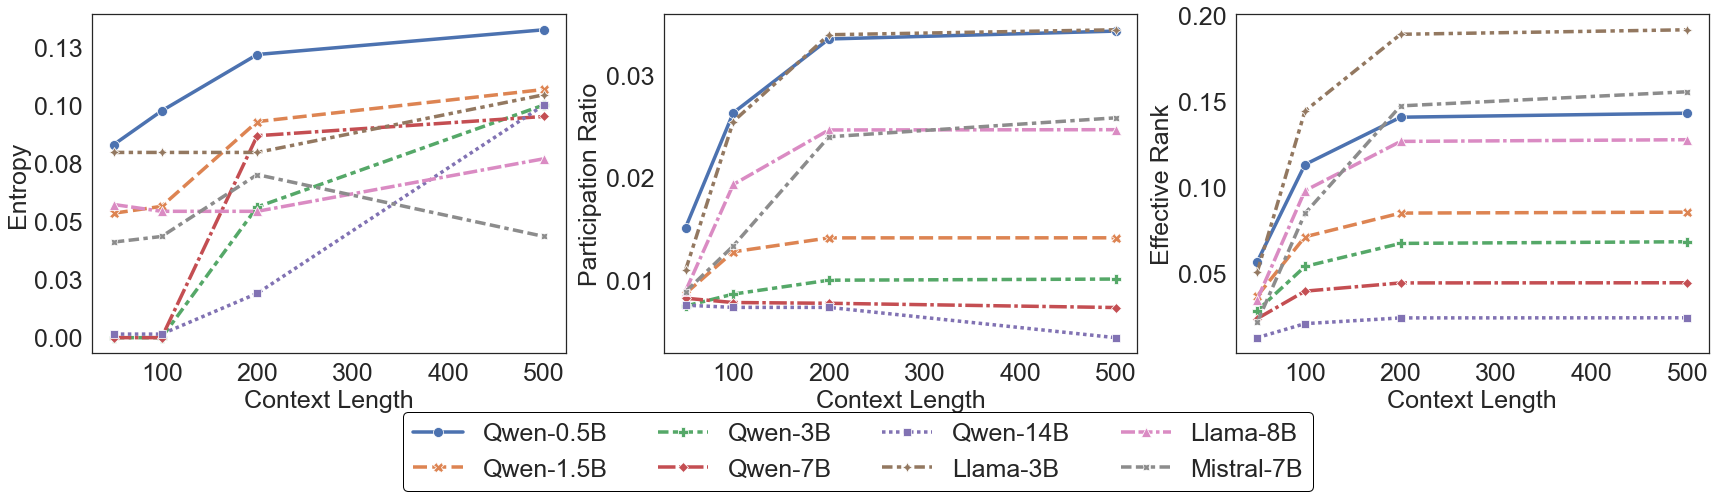

In [30]:
import os
df1 = pd.read_csv("LPP_analysis1_derived.csv")
df1.columns = ['model_name','context_length','entropy', 'participation_ratio', 'effective_rank']

#sns.set(style="whitegrid", palette="muted", font_scale=1.2)
fig, axs = plt.subplots(1, 3, figsize=(24, 6))

formatter = FuncFormatter(lambda x, _: f'{x:.2f}')

metrics = ['entropy', 'participation_ratio', 'effective_rank']

for i, metric in enumerate(metrics):
    sns.lineplot(data=df1, x='context_length', y=metric, hue='model_name', ax=axs[i], markersize=10, hue_order=order, style='model_name', markers=True, linewidth=3.5)
    #axs[i].set_title(f'{metric.replace("_", " ").title()}', fontsize=30) # vs. Context Length
    axs[i].set_xlabel("Context Length", fontsize=25)
    axs[i].set_ylabel(metric.replace("_", " ").title(), fontsize=25)

    if i == 0:
        handles, legend_labels = axs[i].get_legend_handles_labels()
        lines = handles
        labels = legend_labels

    legend = axs[i].legend()
    legend.remove()

    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].tick_params(axis='both', labelsize=25)

    axs[i].grid(False)
    
# Centralized legend below all subplots
fig.legend(
    handles=lines,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.18),
    ncol=4,
    fontsize=25,
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Layout adjustments
#fig.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space at bottom for legend

legend.get_frame().set_linewidth(2)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.04, 
                    hspace=0.2)

fig.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sensitivity_context_length.svg"), format="svg", bbox_inches='tight', dpi=300)

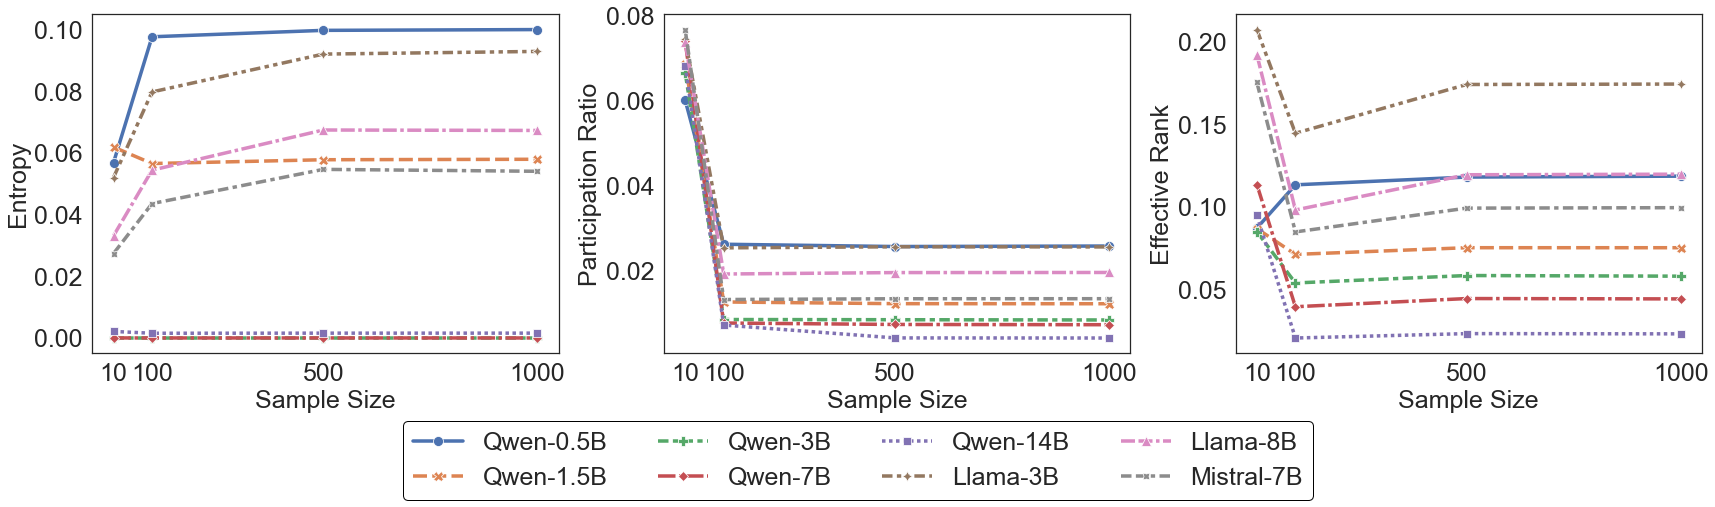

In [33]:
import os
df1 = pd.read_csv("LPP_analysis2.2_derived.csv")

df1.columns = ['model_name','sample_size', 'entropy', 'participation_ratio', 'effective_rank']

#sns.set(style="whitegrid", palette="muted", font_scale=1.2)
fig, axs = plt.subplots(1, 3, figsize=(24, 6))

formatter = FuncFormatter(lambda x, _: f'{x:.2f}')

metrics = ['entropy', 'participation_ratio', 'effective_rank']

for i, metric in enumerate(metrics):
    sns.lineplot(data=df1, x='sample_size', y=metric, hue='model_name', ax=axs[i], markersize=10, hue_order=order, style='model_name', markers=True, linewidth=3.5)
    #axs[i].set_title(f'{metric.replace("_", " ").title()}', fontsize=30) # vs. Context Length
    axs[i].set_xlabel("Sample Size", fontsize=25)
    axs[i].set_xticks([10, 100, 500, 1000])
    axs[i].set_ylabel(metric.replace("_", " ").title(), fontsize=25)

    if i == 0:
        handles, legend_labels = axs[i].get_legend_handles_labels()
        lines = handles
        labels = legend_labels

    legend = axs[i].legend()
    legend.remove()

    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].tick_params(axis='both', labelsize=25)

    axs[i].grid(False)
    
# Centralized legend below all subplots
fig.legend(
    handles=lines,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.2),
    ncol=4,
    fontsize=25,
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Layout adjustments
#fig.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space at bottom for legend

legend.get_frame().set_linewidth(2)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.04, 
                    hspace=0.2)

fig.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "sample_sizes.pdf"), bbox_inches='tight', dpi=300)

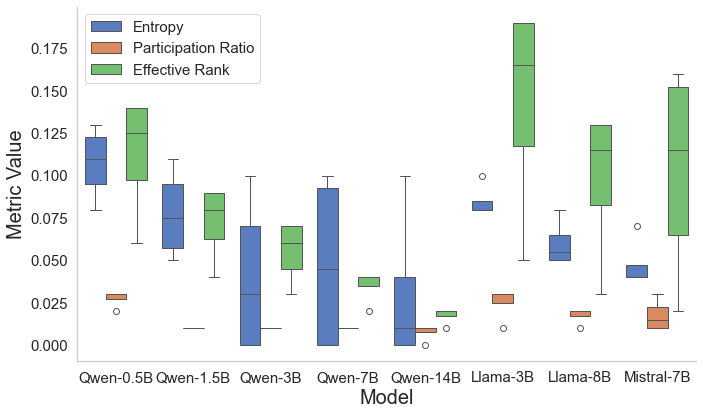

In [167]:
import os
df1 = pd.read_csv("LPP_analysis1_derived.csv")
df1.columns = ['model_name','context_length','Entropy', 'Participation Ratio', 'Effective Rank']

metrics = ['Entropy', 'Participation Ratio', 'Effective Rank']

#for metric in metrics:
#    df_ = df1.groupby(['model_name'])[metric].agg(['min','max']).reset_index(drop=False)
#    df1 = pd.merge(df1, df_, how='inner')
#    df1[metric] = (df1[metric] - df1['min'])/(df1['max'] - df1['min'])
#    df1 = df1.drop(['min','max'], axis=1)
    
df_long = pd.melt(df1, id_vars=['model_name'], value_vars=metrics,
                      var_name='Metric', value_name='Value')

df_long['Value'] = df_long['Value'].apply(lambda x: round(x,2))

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_long, x='model_name', y='Value', hue='Metric', order=order)

#plt.title(f"Distribution w.r.t. Context Length", fontsize=25)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Metric Value", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(-0.5, 1.5)
plt.legend(fontsize=15, title_fontsize=20, loc='upper left')

plt.grid(False)
sns.despine()
plt.tight_layout()
# Save SVG
plt.savefig(os.path.join(FIG_DIR, "sensitivity_context_length_dist.svg"), format="svg", bbox_inches='tight', dpi=300)

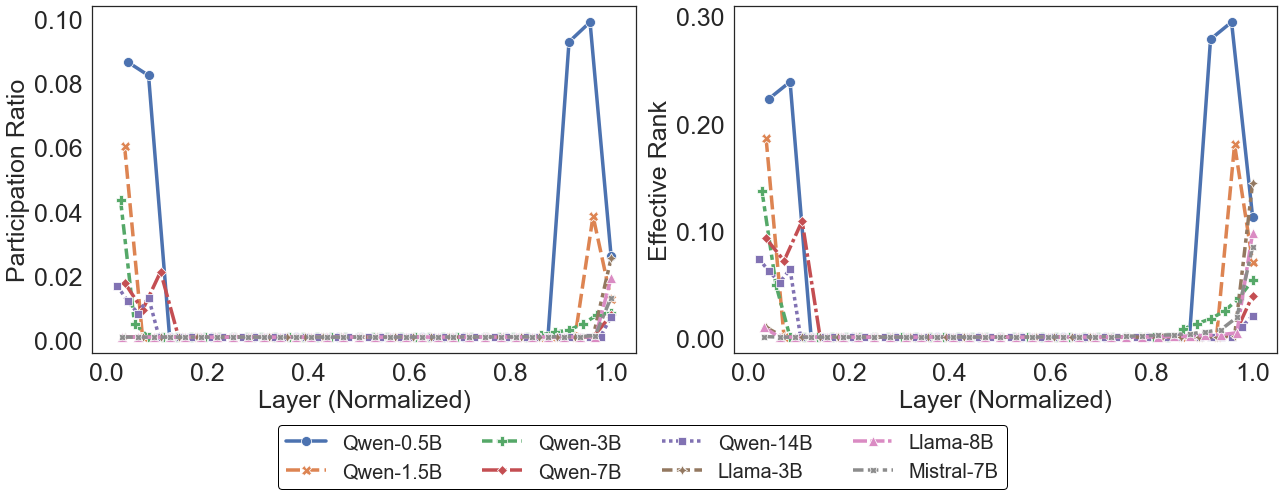

In [31]:
import os
df2 = pd.read_csv("LPP_analysis3.1_derived.csv")
df2.columns = ['model_name','layer', 'participation_ratio', 'effective_rank']

df2 = pd.merge(df2, df2.groupby(['model_name'])['layer'].max().reset_index(drop=False).rename(columns={'layer': 'max_layer'}), how='inner')
df2['layer'] = df2['layer']/df2['max_layer']

formatter = FuncFormatter(lambda x, _: f'{x:.2f}')

fig2, axs2 = plt.subplots(1, 2, figsize=(18, 6), sharex=True)
metrics2 = ['participation_ratio', 'effective_rank']

for i, metric in enumerate(metrics2):
    ax = axs2[i]
    sns.lineplot(data=df2, x='layer', y=metric, hue='model_name', ax=axs2[i], markersize=10, hue_order=order, style='model_name', markers=True, linewidth=3.5)
    #ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=30)
    ax.set_xlabel("Layer (Normalized)", fontsize=25)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=25)

    if i == 0:
        handles, legend_labels = axs2[i].get_legend_handles_labels()
        lines = handles
        labels = legend_labels

    legend = axs2[i].legend()
    legend.remove()

    axs2[i].yaxis.set_major_formatter(formatter)
    axs2[i].tick_params(axis='both', labelsize=25)

    axs2[i].grid(False)
    
# Centralized legend below all subplots
fig2.legend(
    handles=lines,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.17),
    ncol=4,
    fontsize=20,
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Layout adjustments
#fig.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space at bottom for legend

legend.get_frame().set_linewidth(2)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.2)

fig2.tight_layout()

fig2.savefig(os.path.join(FIG_DIR, "layerwise_stats.pdf"), bbox_inches='tight', dpi=300)

In [169]:
import os
'''
df2 = pd.read_csv("LPP_analysis3.1_derived.csv")
df2.columns = ['model_name','layer', 'Participation Ratio', 'Effective Rank']

metrics = ['Participation Ratio', 'Effective Rank']

df_long = pd.melt(df2, id_vars=['model_name'], value_vars=metrics,
                      var_name='Metric', value_name='Value')

df_long['Value'] = df_long['Value'].apply(lambda x: round(x,2))

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_long, x='model_name', y='Value', hue='Metric', order=order)

plt.title(f"Distribution w.r.t. Model Layer", fontsize=25)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Metric Value", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(-0.5, 1.5)
plt.legend(fontsize=15, title_fontsize=20, loc='upper left')

plt.grid(False)
sns.despine()
plt.tight_layout()
# Save SVG
plt.savefig(os.path.join(FIG_DIR, "temporal_trend_layers_dist.svg"), format="svg", bbox_inches='tight', dpi=300)
'''

'\ndf2 = pd.read_csv("LPP_analysis3.1_derived.csv")\ndf2.columns = [\'model_name\',\'layer\', \'Participation Ratio\', \'Effective Rank\']\n\nmetrics = [\'Participation Ratio\', \'Effective Rank\']\n\ndf_long = pd.melt(df2, id_vars=[\'model_name\'], value_vars=metrics,\n                      var_name=\'Metric\', value_name=\'Value\')\n\ndf_long[\'Value\'] = df_long[\'Value\'].apply(lambda x: round(x,2))\n\n# Plot\nplt.figure(figsize=(10, 6))\nsns.boxplot(data=df_long, x=\'model_name\', y=\'Value\', hue=\'Metric\', order=order)\n\nplt.title(f"Distribution w.r.t. Model Layer", fontsize=25)\nplt.xlabel("Model", fontsize=20)\nplt.ylabel("Metric Value", fontsize=20)\nplt.xticks(fontsize=15)\nplt.yticks(fontsize=15)\n#plt.ylim(-0.5, 1.5)\nplt.legend(fontsize=15, title_fontsize=13, loc=\'upper left\')\n\nplt.grid(False)\nsns.despine()\nplt.tight_layout()\n# Save SVG\nplt.savefig("temporal_trend_layers_dist.svg", format="svg", bbox_inches=\'tight\', dpi=300)\n'

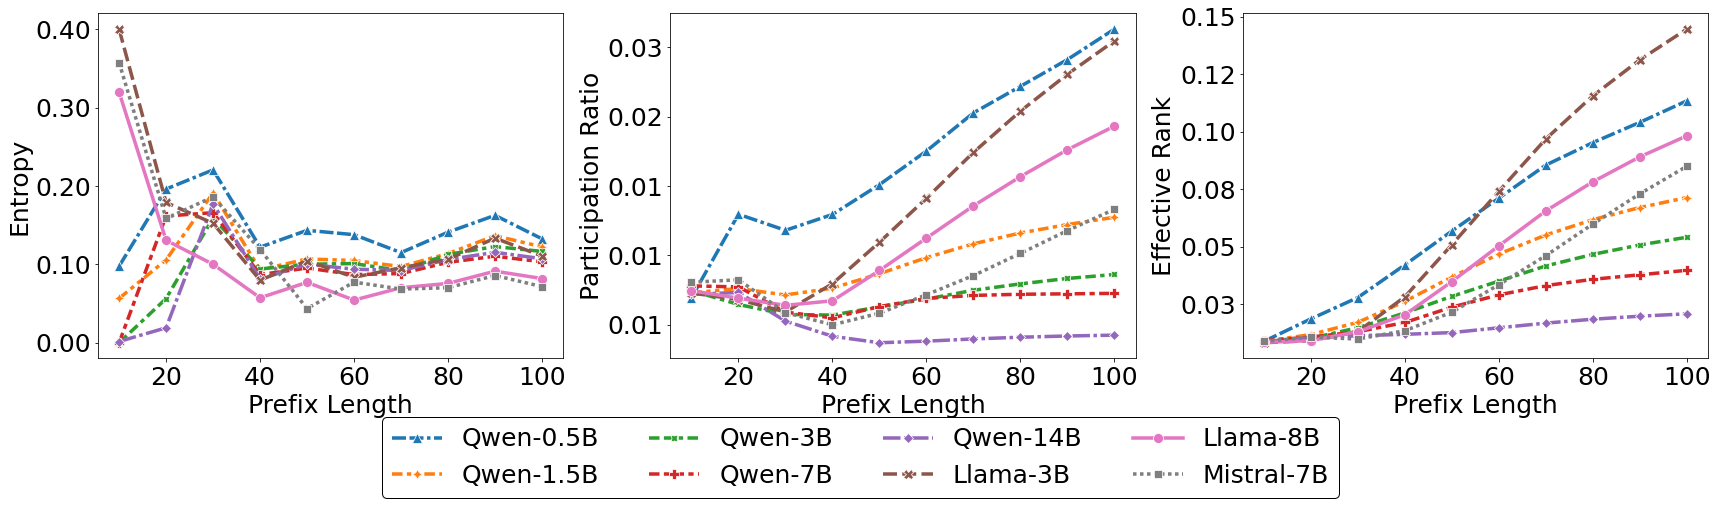

In [19]:
import os
df3 = pd.read_csv("LPP_analysis3.2_derived.csv")

df3.columns = ['model_name','prefix_tokens', 'dataset', 'context_length', 'entropy', 'participation_ratio', 'effective_rank']

formatter = FuncFormatter(lambda x, _: f'{x:.2f}')

fig3, axs3 = plt.subplots(1, 3, figsize=(24, 6))
metrics3 = ['entropy', 'participation_ratio', 'effective_rank']

for i, metric in enumerate(metrics3):
    ax = axs3[i]
    sns.lineplot(data=df3, x='prefix_tokens', y=metric, hue='model_name', ax=axs3[i], markersize=10, hue_order=order, style='model_name', markers=True, linewidth=3.5)
    #ax.set_title(f'{metric.replace("_", " ").title()}', fontsize=30)
    ax.set_xlabel("Prefix Length", fontsize=25)
    ax.set_ylabel(metric.replace("_", " ").title(), fontsize=25)

    if i == 0:
        handles, legend_labels = axs3[i].get_legend_handles_labels()
        lines = handles
        labels = legend_labels

    legend = axs3[i].legend()
    legend.remove()

    axs3[i].yaxis.set_major_formatter(formatter)
    axs3[i].tick_params(axis='both', labelsize=25)

    axs3[i].grid(False)
    
# Centralized legend below all subplots
fig3.legend(
    handles=lines,
    labels=labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.19),
    ncol=4,
    fontsize=25,
    frameon=True,
    framealpha=1,
    edgecolor='black'
)

# Layout adjustments
#fig.tight_layout(rect=[0, 0.1, 1, 1])  # Leave space at bottom for legend

legend.get_frame().set_linewidth(2)

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.23, 
                    hspace=0.2)

fig3.tight_layout()

fig3.savefig(os.path.join(FIG_DIR, "temporal_trend_prefil_length.svg"), format="svg", bbox_inches='tight', dpi=300)

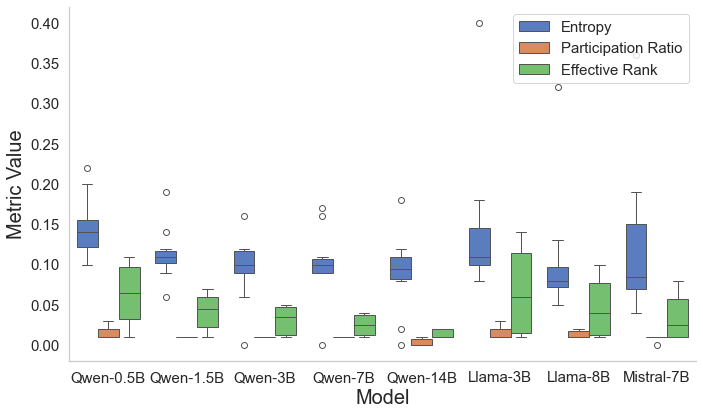

In [171]:
import os
df3 = pd.read_csv("LPP_analysis3.2_derived.csv")

df3.columns = ['model_name','prefix_tokens', 'dataset', 'context_length', 'Entropy', 'Participation Ratio', 'Effective Rank']

metrics = ['Entropy', 'Participation Ratio', 'Effective Rank']

df_long = pd.melt(df3, id_vars=['model_name'], value_vars=metrics,
                      var_name='Metric', value_name='Value')

df_long['Value'] = df_long['Value'].apply(lambda x: round(x,2))

# Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_long, x='model_name', y='Value', hue='Metric', order=order)

#plt.title(f"Distribution w.r.t. Prefix Length", fontsize=25)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Metric Value", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(-0.5, 1.5)
plt.legend(fontsize=15, title_fontsize=20, loc='upper right')

plt.grid(False)
sns.despine()
plt.tight_layout()
# Save SVG
plt.savefig(os.path.join(FIG_DIR, "temporal_trend_prefil_length_dist.svg"), format="svg", bbox_inches='tight', dpi=300)

In [21]:
import numpy as np

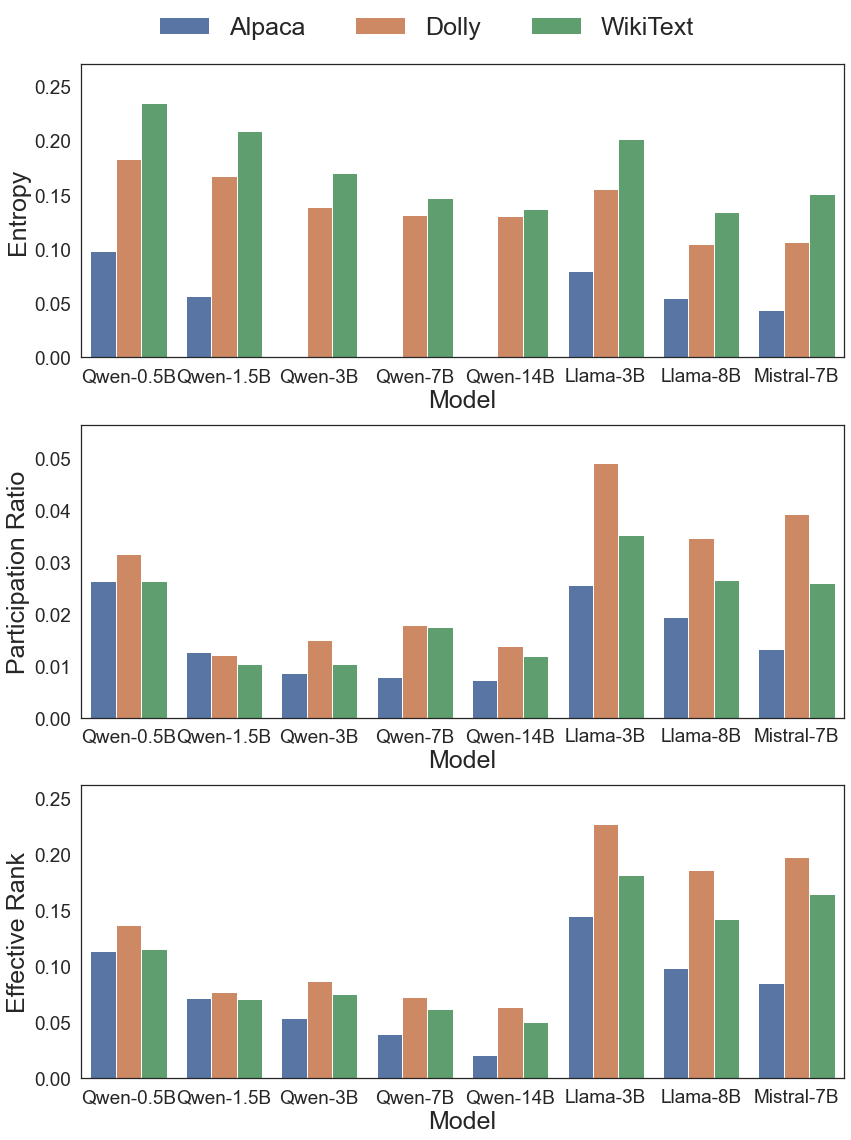

In [28]:
import os
fp = "LPP_analysis2.1_derived.csv"
df = pd.read_csv(fp)

rename_map = {
    'model': 'model_id',
    'model_name': 'model_id',
    'mean_entropy': 'mean_next_token_entropy',
    'entropy': 'mean_next_token_entropy',
    'participation': 'participation_ratio',
    'eff_rank': 'effective_rank',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Ensure required columns exist
req = ['model_id', 'dataset', 'mean_next_token_entropy', 'participation_ratio', 'effective_rank']
missing = [c for c in req if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}. Available: {list(df.columns)}")

# Optional: sort models/datasets in a fixed order
model_order = sorted(df['model_id'].unique(), key=lambda x: (x.split('-')[-1] if '-' in x else x))
dataset_order = sorted(df['dataset'].unique())

df['model_id'] = pd.Categorical(df['model_id'], categories=model_order, ordered=True)
df['dataset'] = pd.Categorical(df['dataset'], categories=dataset_order, ordered=True)

# --- Plot ---
sns.set_theme(style="white")
fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=False)

plotspec = [
    ("mean_next_token_entropy", "Entropy"),
    ("participation_ratio",     "Participation Ratio"),
    ("effective_rank",          "Effective Rank"),
]

# Compute y-limits with a small headroom for each metric
ylims = {}
for col, _ in plotspec:
    ymax = np.nanmax(df[col].values)
    ylims[col] = (0, ymax * 1.15 if np.isfinite(ymax) and ymax > 0 else 1)

for ax, (ycol, ylabel) in zip(axes, plotspec):
    sns.barplot(
        data=df,
        x="model_id", y=ycol, hue="dataset", order=order,
        ax=ax, errorbar=None, width=0.8
    )
    ax.set_xlabel("Model", fontsize=25)
    ax.set_ylabel(ylabel, fontsize=25)
    ax.set_ylim(*ylims[ycol])
    ax.tick_params(axis='x', rotation=0, labelsize=19)
    ax.tick_params(axis='y', rotation=0, labelsize=19)

    
    # Put per-axes legend to None; we'll add one shared legend later
    ax.legend_.remove()


# Shared legend (from first axes)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="", loc="upper center", ncol=len(dataset_order), \
           fontsize=25, frameon=False, bbox_to_anchor=(0.5, 1))

plt.tight_layout(rect=(0, 0, 1, 0.95))
# Optional: save to file
plt.savefig(os.path.join(FIG_DIR, "lpp_three_metrics_subplots.pdf"), dpi=300, bbox_inches="tight")
#plt.show()

In [9]:
import seaborn as sns

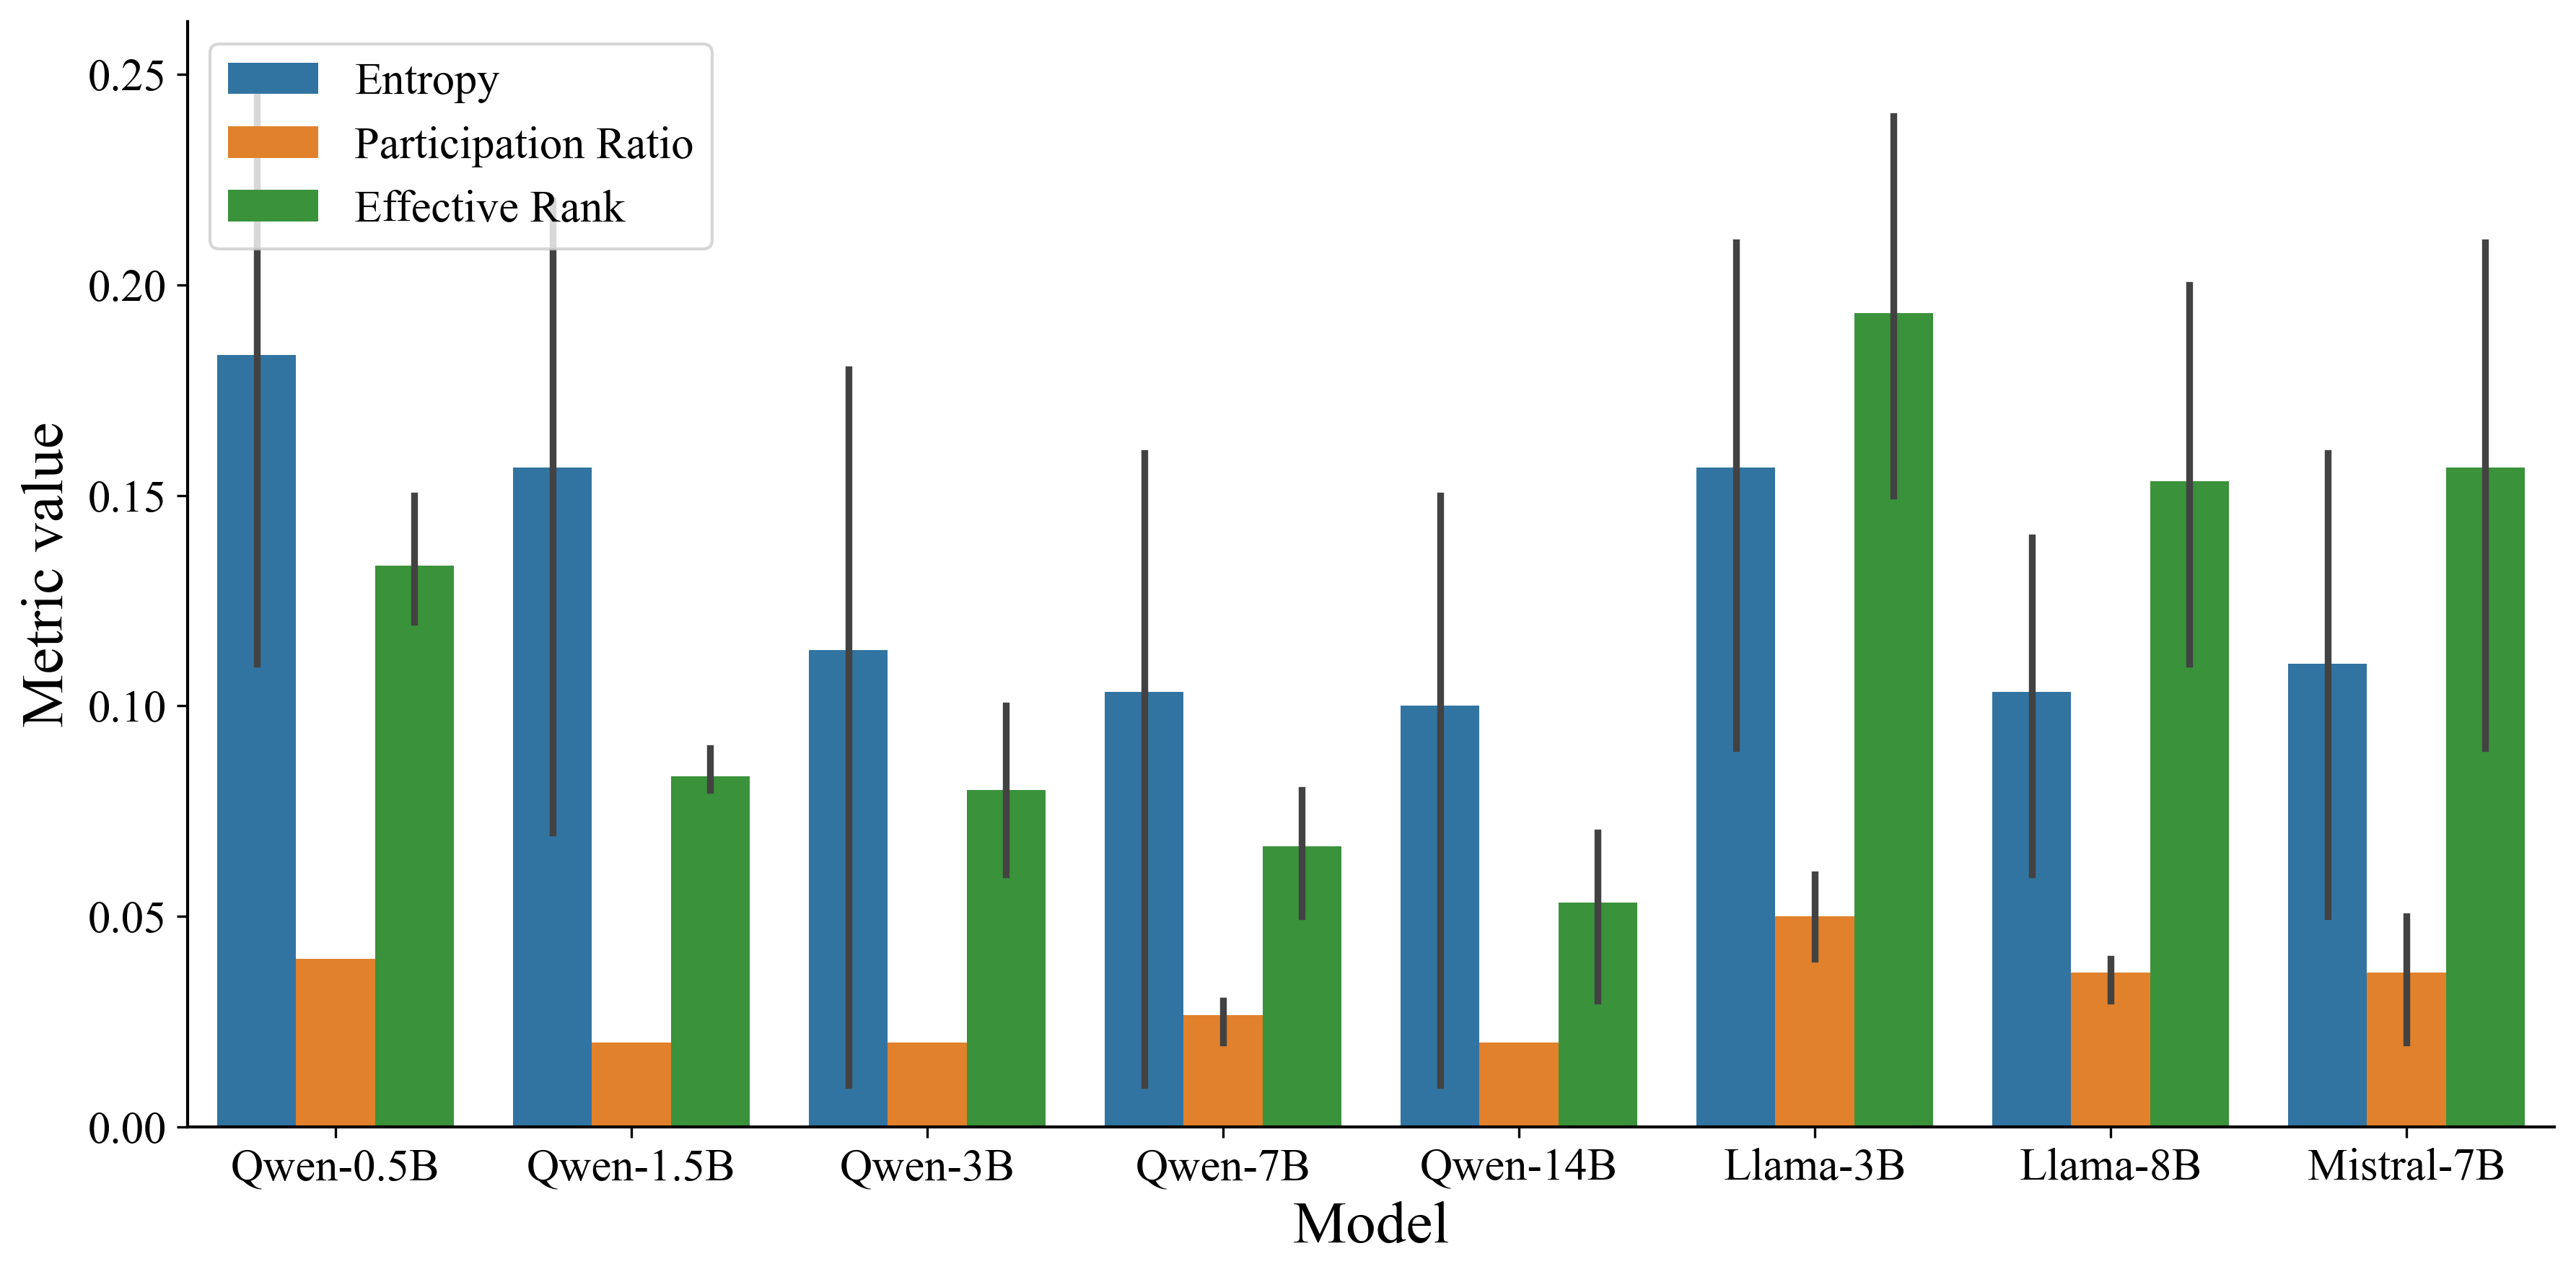

In [21]:
import os
df2 = pd.read_csv("LPP_analysis2.1_derived.csv")

df2.columns = ['model_name','dataset', 'Entropy', 'Participation Ratio', 'Effective Rank']

metrics = ['Entropy', 'Participation Ratio', 'Effective Rank']

df_long = pd.melt(df2, id_vars=['model_name','dataset'], value_vars=metrics,
                      var_name='Metric', value_name='Value')

df_long['Value'] = df_long['Value'].apply(lambda x: round(x,2)+0.01)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_long, x='model_name', y='Value', hue='Metric', order=order)

#plt.title(f"Distribution w.r.t. Prefix Length", fontsize=25)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Metric value", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(-0.5, 1.5)
plt.legend(fontsize=15, title_fontsize=20, loc='upper left')

plt.grid(False)
sns.despine()
plt.tight_layout()
# Save SVG
plt.savefig(os.path.join(FIG_DIR, "dist_samplesize.svg"), format="svg", bbox_inches='tight', dpi=300)

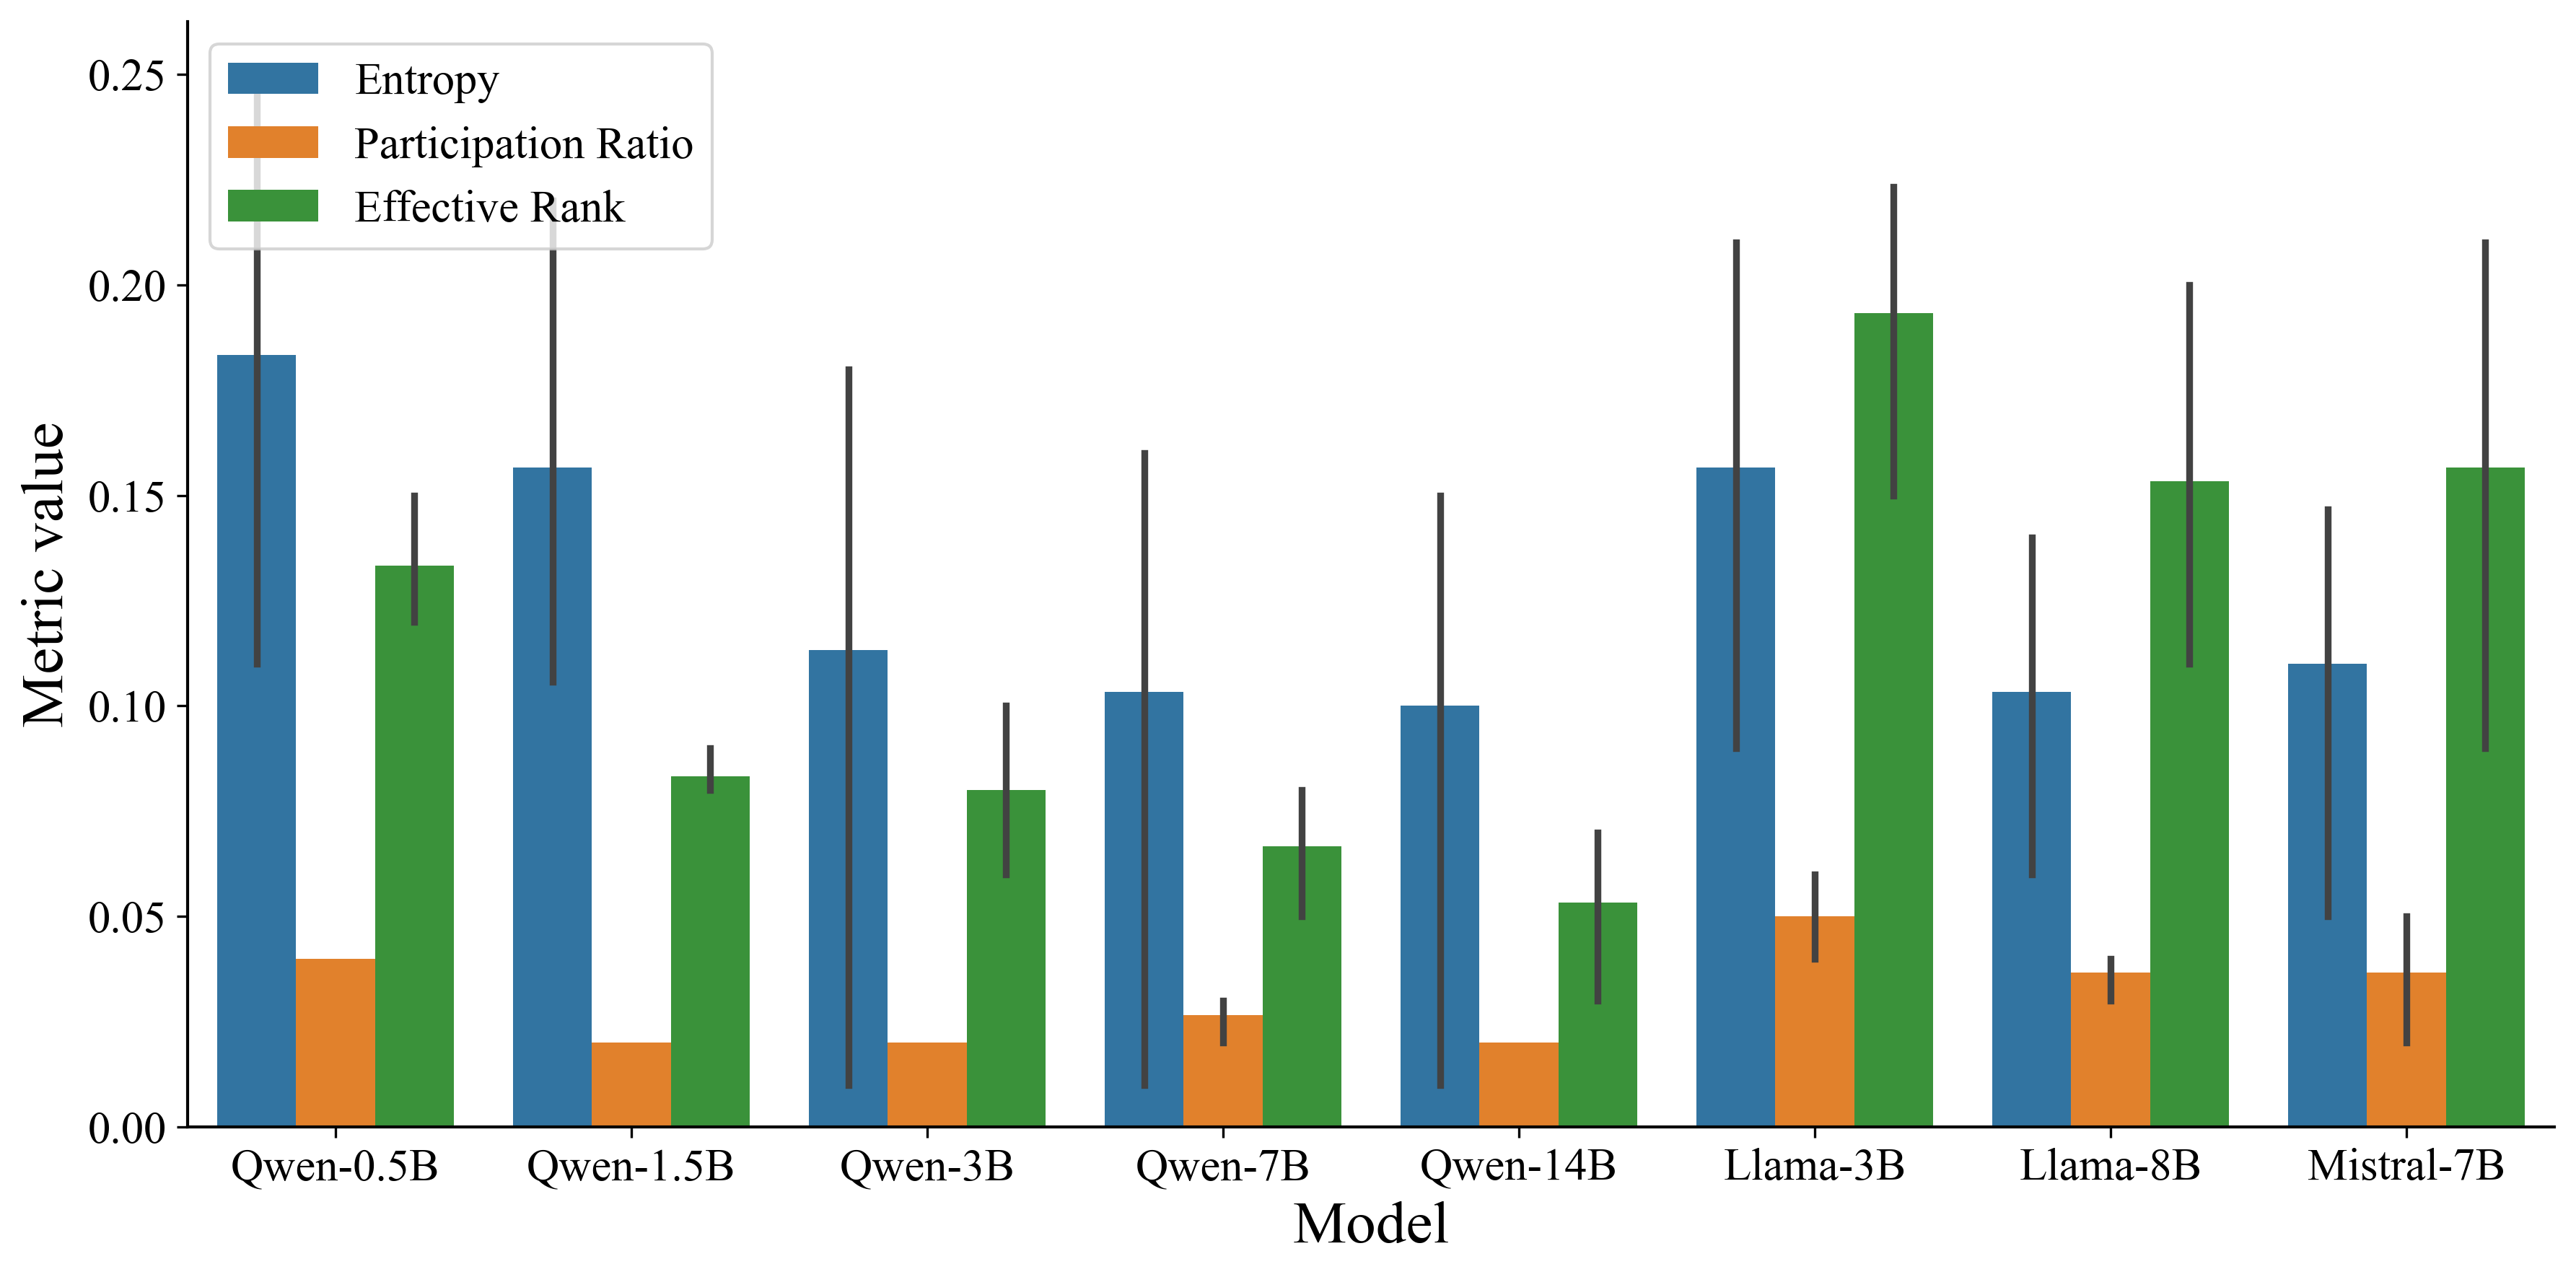

In [20]:
import os
df2 = pd.read_csv("LPP_analysis2.1_derived.csv")

df2.columns = ['model_name','dataset', 'Entropy', 'Participation Ratio', 'Effective Rank']

metrics = ['Entropy', 'Participation Ratio', 'Effective Rank']

df_long = pd.melt(df2, id_vars=['model_name'], value_vars=metrics,
                      var_name='Metric', value_name='Value')

df_long['Value'] = df_long['Value'].apply(lambda x: round(x,2)+0.01)

order.reverse()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_long, x='model_name', y='Value', hue='Metric', order=order)

#plt.title(f"Distribution w.r.t. Prefix Length", fontsize=25)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Metric value", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(-0.5, 1.5)
plt.legend(fontsize=15, title_fontsize=20, loc='upper left')

plt.grid(False)
sns.despine()
plt.tight_layout()
# Save SVG
plt.savefig(os.path.join(FIG_DIR, "dist_dataset.svg"), format="svg", bbox_inches='tight', dpi=300)

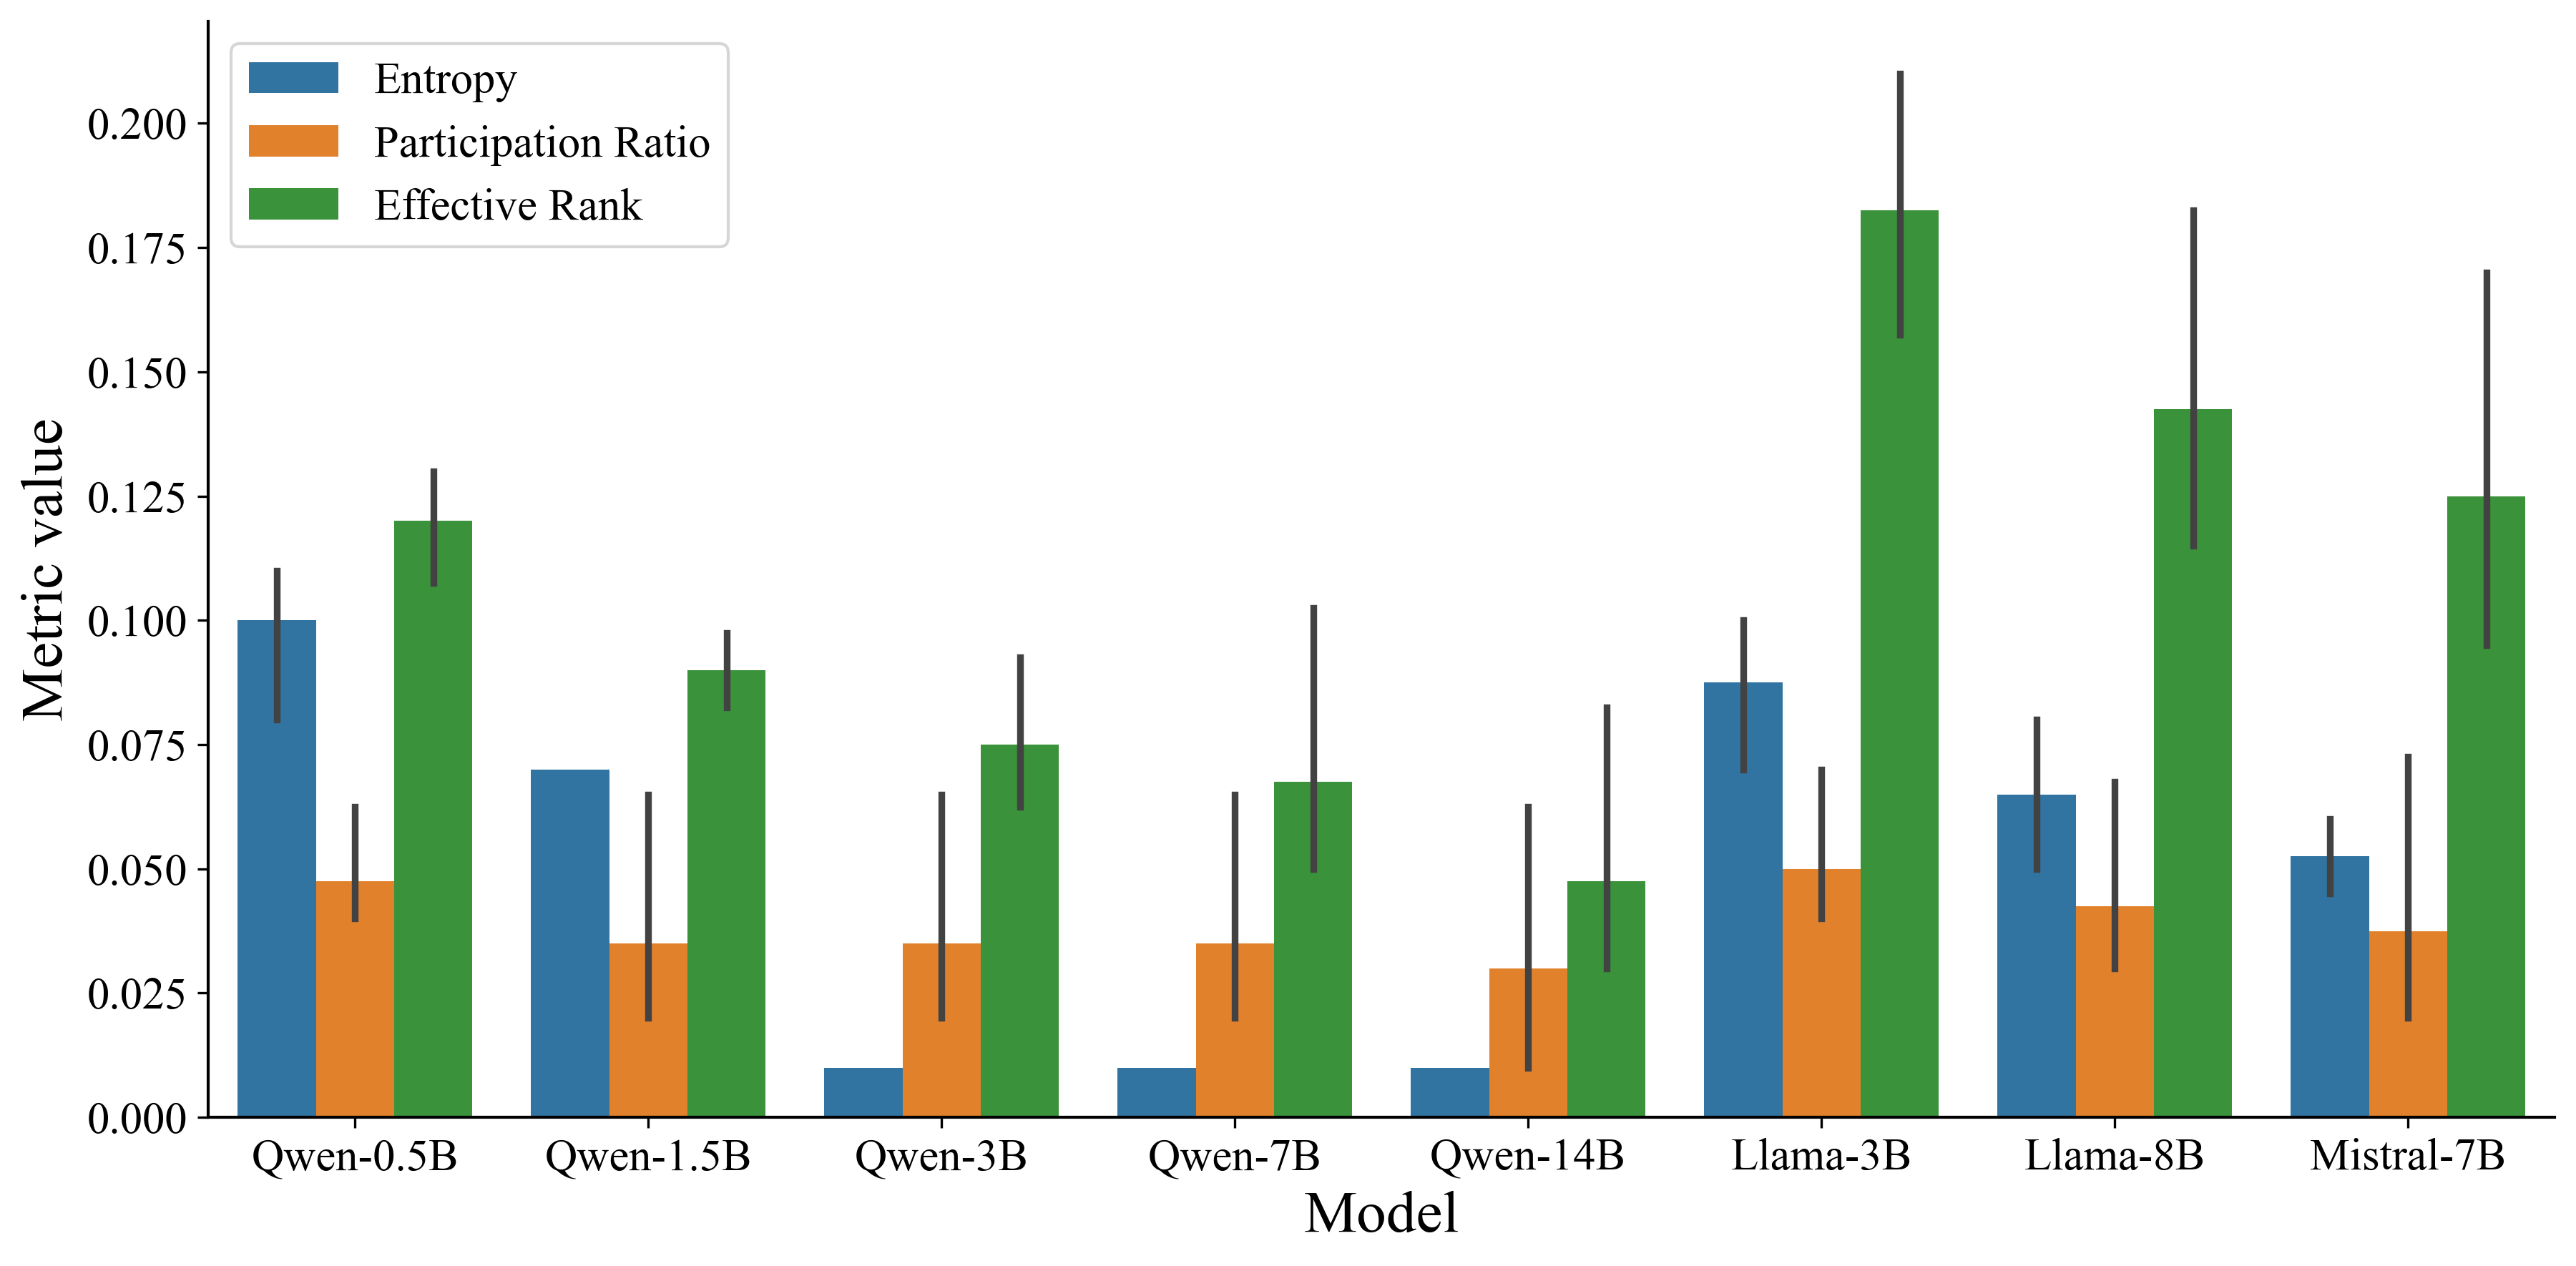

In [22]:
import os
df2 = pd.read_csv("LPP_analysis2.2_derived.csv")

df2.columns = ['model_name','sample_size', 'Entropy', 'Participation Ratio', 'Effective Rank']

metrics = ['Entropy', 'Participation Ratio', 'Effective Rank']

df_long = pd.melt(df2, id_vars=['model_name'], value_vars=metrics,
                      var_name='Metric', value_name='Value')

df_long['Value'] = df_long['Value'].apply(lambda x: round(x,2)+0.01)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df_long, x='model_name', y='Value', hue='Metric', order=order)

#plt.title(f"Distribution w.r.t. Prefix Length", fontsize=25)
plt.xlabel("Model", fontsize=20)
plt.ylabel("Metric value", fontsize=20)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
#plt.ylim(-0.5, 1.5)
plt.legend(fontsize=15, title_fontsize=20, loc='upper left')

plt.grid(False)
sns.despine()
plt.tight_layout()
# Save SVG
plt.savefig(os.path.join(FIG_DIR, "dist_samplesize.svg"), format="svg", bbox_inches='tight', dpi=300)

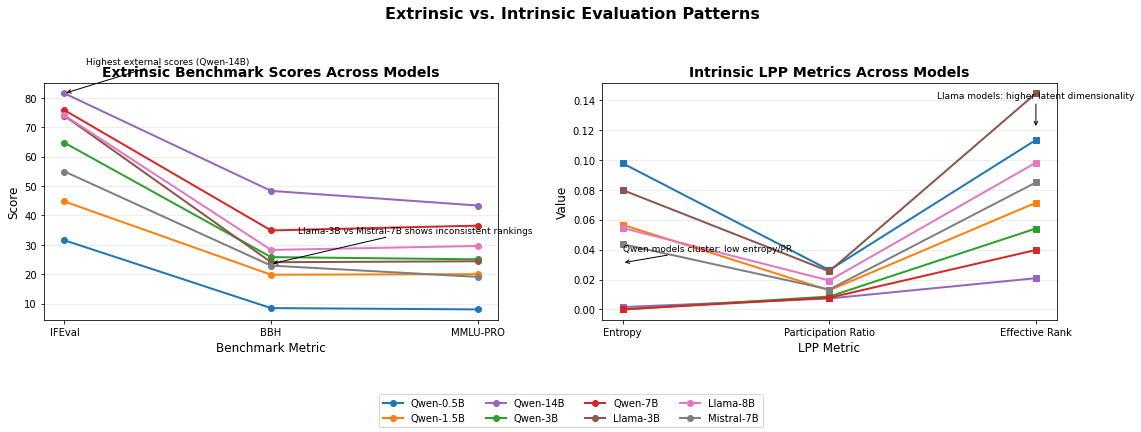

In [32]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data
df = pd.read_csv('plot_data.csv')

# Define metric groups
extrinsic_metrics = ['IFEval', 'BBH', 'MMLU-PRO']
lpp_metrics = ['Entropy', 'Participation Ratio', 'Effective Rank']

# Colour palette for each model
model_palette = {
    'Qwen-0.5B': '#1f77b4', 'Qwen-1.5B': '#ff7f0e', 'Qwen-3B': '#2ca02c',
    'Qwen-7B': '#d62728', 'Qwen-14B': '#9467bd', 'Llama-3B': '#8c564b',
    'Llama-8B': '#e377c2', 'Mistral-7B': '#7f7f7f'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
plt.subplots_adjust(wspace=0.3, bottom=0.3)

# --- Plot 1: Extrinsic metrics ---
for model in df['Model']:
    row = df[df['Model'] == model].iloc[0]
    scores = [row[m] for m in extrinsic_metrics]
    axes[0].plot(extrinsic_metrics, scores, marker='o',
                 color=model_palette[model], linewidth=2, label=model)

axes[0].set_title('Extrinsic Benchmark Scores Across Models', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Benchmark Metric', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].tick_params(axis='both', labelsize=10)
axes[0].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

# Annotate interesting extrinsic patterns
# Highest across all benchmarks
qwen14 = df[df['Model'] == 'Qwen-14B'].iloc[0]
axes[0].annotate('Highest external scores (Qwen-14B)',
                 xy=(extrinsic_metrics.index('IFEval'), qwen14['IFEval']),
                 xytext=(0.5, qwen14['IFEval'] + 10),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, ha='center')

# Contrasting performance between similarly sized models
llama3 = df[df['Model'] == 'Llama-3B'].iloc[0]
mistral7 = df[df['Model'] == 'Mistral-7B'].iloc[0]
axes[0].annotate(
    'Llama-3B vs Mistral-7B shows inconsistent rankings',
    xy=(extrinsic_metrics.index('BBH'), (llama3['BBH'] + mistral7['BBH']) / 2),
    xytext=(1.7, max(llama3['BBH'], mistral7['BBH']) + 10),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, ha='center'
)

# --- Plot 2: Intrinsic LPP metrics ---
for model in df['Model']:
    row = df[df['Model'] == model].iloc[0]
    scores = [row[m] for m in lpp_metrics]
    axes[1].plot(lpp_metrics, scores, marker='s',
                 color=model_palette[model], linewidth=2, label=model)

axes[1].set_title('Intrinsic LPP Metrics Across Models', fontsize=14, fontweight='bold')
axes[1].set_xlabel('LPP Metric', fontsize=12)
axes[1].set_ylabel('Value', fontsize=12)
axes[1].tick_params(axis='both', labelsize=10)
axes[1].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)

# Annotate LPP patterns
# Qwen family cluster with low entropy and PR
qwen_family = df[df['Model'].str.contains('Qwen')]
avg_entropy = qwen_family['Entropy'].mean()
avg_pr = qwen_family['Participation Ratio'].mean()
axes[1].annotate(
    'Qwen models cluster: low entropy/PR',
    xy=(lpp_metrics.index('Entropy'), avg_entropy),
    xytext=(0.0, avg_entropy + 0.008),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, ha='left'
)

# Llama models show higher latent capacity
llama_family = df[df['Model'].str.contains('Llama')]
avg_rank = llama_family['Effective Rank'].mean()
axes[1].annotate(
    'Llama models: higher latent dimensionality',
    xy=(lpp_metrics.index('Effective Rank'), avg_rank),
    xytext=(2, avg_rank + 0.02),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9, ha='center'
)

# Create a single legend beneath the plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10, frameon=True)

plt.suptitle('Extrinsic vs. Intrinsic Evaluation Patterns', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.15, 1, 0.95])

# Save as high-resolution SVG
plt.savefig(os.path.join(FIG_DIR, "llm_comparison_plots.svg"), format='svg')
plt.show()


In [34]:
df

,Model,IFEval,BBH,MMLU-PRO,Entropy,Participation Ratio,Effective Rank
0,Qwen-0.5B,31.529121,8.434864,7.995346,0.097729,0.026310,0.113367
1,Qwen-1.5B,44.755693,19.809787,19.991135,0.056605,0.012742,0.071355
2,Qwen-14B,81.577769,48.360707,43.382462,0.001551,0.007315,0.020861
3,Qwen-3B,64.749199,25.801394,25.051714,0.000004,0.008612,0.054108
4,Qwen-7B,75.852516,34.892117,36.521129,0.000022,0.007790,0.039750
5,Llama-3B,73.931613,24.059186,24.386820,0.079830,0.025459,0.144525
6,Llama-8B,74.083986,28.244950,29.604388,0.054458,0.019312,0.098168
7,Mistral-7B,54.962278,22.910602,19.076906,0.043618,0.013314,0.084933


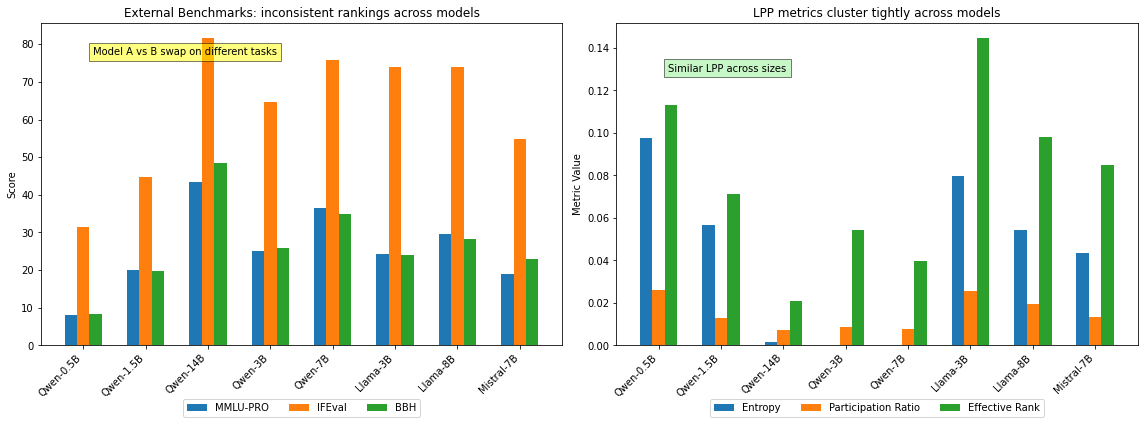

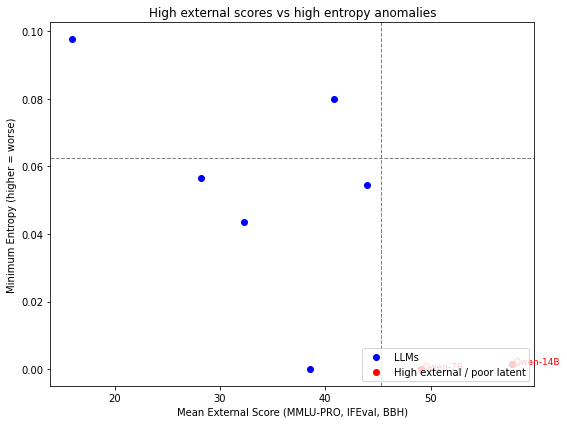

In [36]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the combined metrics file
df = pd.read_csv("plot_data.csv")

# Normalize or standardize external and latent metrics to compare across scales
external_cols = ['MMLU-PRO', 'IFEval', 'BBH']
latent_cols = ['Entropy', 'Participation Ratio', 'Effective Rank']

# Compute means for plotting and anomaly detection
df['External_Mean'] = df[external_cols].mean(axis=1)
df['Latent_Mean'] = df[latent_cols].mean(axis=1)

# Create a 1×2 subplot layout
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------------------------------------------------
# Subplot 1: Extrinsic metrics show inconsistent rankings
# Plot each external metric as a separate bar for each model
bar_width = 0.2
x = np.arange(len(df))
for idx, col in enumerate(external_cols):
    axes[0].bar(x + idx*bar_width, df[col], width=bar_width, label=col)
axes[0].set_xticks(x + bar_width)
axes[0].set_xticklabels(df['Model'], rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('External Benchmarks: inconsistent rankings across models')
# Annotate a notable discrepancy (example: models with reversed ordering)
# Replace 'Model_A', 'Model_B' with actual names after inspecting the data
axes[0].annotate(
    'Model A vs B swap on different tasks',
    xy=(0.1, 0.9),
    xycoords='axes fraction',
    fontsize=10,
    bbox=dict(facecolor='yellow', alpha=0.5)
)
axes[0].legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))

# -------------------------------------------------------------------
# Subplot 2: Latent metrics cluster more tightly
bar_width = 0.2
for idx, col in enumerate(latent_cols):
    axes[1].bar(x + idx*bar_width, df[col], width=bar_width, label=col)
axes[1].set_xticks(x + bar_width)
axes[1].set_xticklabels(df['Model'], rotation=45, ha='right')
axes[1].set_ylabel('Metric Value')
axes[1].set_title('LPP metrics cluster tightly across models')
# Annotate a model with similar latent profile despite different sizes
axes[1].annotate(
    'Similar LPP across sizes',
    xy=(0.1, 0.85),
    xycoords='axes fraction',
    fontsize=10,
    bbox=dict(facecolor='lightgreen', alpha=0.5)
)
axes[1].legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "external_vs_latent_metrics.svg"), format='svg')

# -------------------------------------------------------------------
# Identify models with high external scores but poor latent metrics
# Define thresholds based on quantiles or domain knowledge:
high_external_threshold = df['External_Mean'].quantile(0.75)
high_entropy_threshold = df['Entropy'].quantile(0.75)   # high entropy is undesirable
low_rank_threshold    = df['Effective Rank'].quantile(0.25)        # low effective rank is undesirable
low_pr_threshold      = df['Participation Ratio'].quantile(0.25)        # low participation ratio is undesirable

# Identify anomalies: high external mean AND any poor latent metric
anomalies = df[
    (df['External_Mean'] >= high_external_threshold) &
    (
        (df['Entropy'] >= high_entropy_threshold) |
        (df['Effective Rank'] <= low_rank_threshold) |
        (df['Participation Ratio'] <= low_pr_threshold)
    )
]

# Scatter plot to highlight anomalies
plt.figure(figsize=(8, 6))
plt.scatter(df['External_Mean'], df['Entropy'], color='blue', label='LLMs')
plt.scatter(
    anomalies['External_Mean'],
    anomalies['Entropy'],
    color='red',
    label='High external / poor latent'
)
for i, row in anomalies.iterrows():
    plt.text(
        row['External_Mean'] + 0.1,
        row['Entropy'],
        row['Model'],
        fontsize=9,
        color='red'
    )
plt.axvline(high_external_threshold, color='grey', linestyle='--', linewidth=1)
plt.axhline(high_entropy_threshold, color='grey', linestyle='--', linewidth=1)
plt.title('High external scores vs high entropy anomalies')
plt.xlabel('Mean External Score (MMLU‑PRO, IFEval, BBH)')
plt.ylabel('Minimum Entropy (higher = worse)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "external_vs_entropy_anomalies.svg"), format='svg')


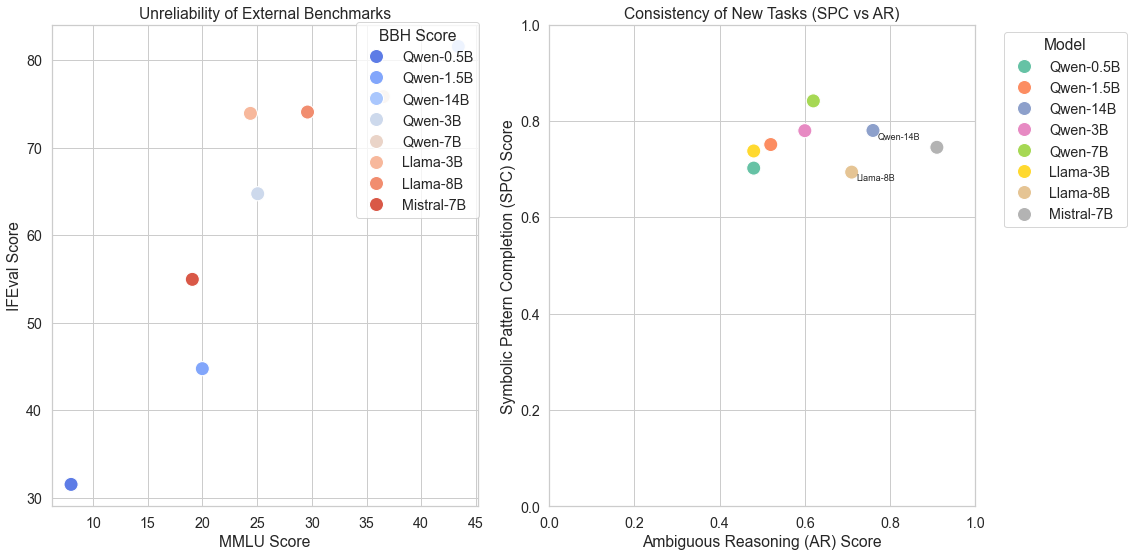

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset; adjust filepath if necessary
df = pd.read_csv("plot_data2.csv")

# ----- Subplot 1: External Benchmarks -----
# We will plot MMLU vs IFEval and colour by BBH to demonstrate variability.
# Adjust the figure size and aesthetics for readability.
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
sns.set(style="whitegrid", font_scale=1.3)

# Scatter plot for external benchmarks (MMLU vs IFEval).
scatter = sns.scatterplot(
    data=df,
    x="MMLU", y="IFEval",
    hue="fullname",
    palette="coolwarm",
    s=200,
    ax=axs[0]
)

axs[0].set_title("Unreliability of External Benchmarks")
axs[0].set_xlabel("MMLU Score")
axs[0].set_ylabel("IFEval Score")

# Add annotations to highlight notable patterns:
# - High MMLU but low IFEval
# - High IFEval but low MMLU
for i, row in df.iterrows():
    # example condition for annotation; adjust thresholds based on actual data
    if (row["MMLU"] > 80 and row["IFEval"] < 20) or (row["IFEval"] > 80 and row["MMLU"] < 20):
        axs[0].annotate(
            row["fullname"],
            (row["MMLU"], row["IFEval"]),
            textcoords="offset points",
            xytext=(5, 5),
            ha='left', fontsize=10
        )

axs[0].legend(title="BBH Score", loc='upper right', bbox_to_anchor=(1.02, 1.02))

# ----- Subplot 2: New LPP tasks (SPC vs AR) -----
sns.scatterplot(
    data=df,
    x="AR", y="SPC",
    hue="fullname",
    palette="Set2",
    s=200,
    ax=axs[1]
)

axs[1].set_title("Consistency of New Tasks (SPC vs AR)")
axs[1].set_xlabel("Ambiguous Reasoning (AR) Score")
axs[1].set_ylabel("Symbolic Pattern Completion (SPC) Score")
axs[1].set_xlim(0, 1)  # assuming scores in [0,1]
axs[1].set_ylim(0, 1)

# Annotate key patterns:
for i, row in df.iterrows():
    # Example: highlight models that cluster tightly (close to diagonal line)
    if abs(row["AR"] - row["SPC"]) < 0.05:
        axs[1].annotate(
            row["fullname"],
            (row["AR"], row["SPC"]),
            textcoords="offset points",
            xytext=(5, -8),
            ha='left', fontsize=9
        )

axs[1].legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')

# Adjust layout and show plot
plt.tight_layout()
plt.show()


/var/folders/pz/5lsvsk5s79q_8bbzj9jj5vv00000gn/T/ipykernel_87439/191617554.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("tab10") if n_models <= 10 else get_cmap("tab20")


Saved SVGs: plot1_extrinsic_metrics.svg, plot2_intrinsic_metrics.svg, plot3_synthetic_tasks.svg


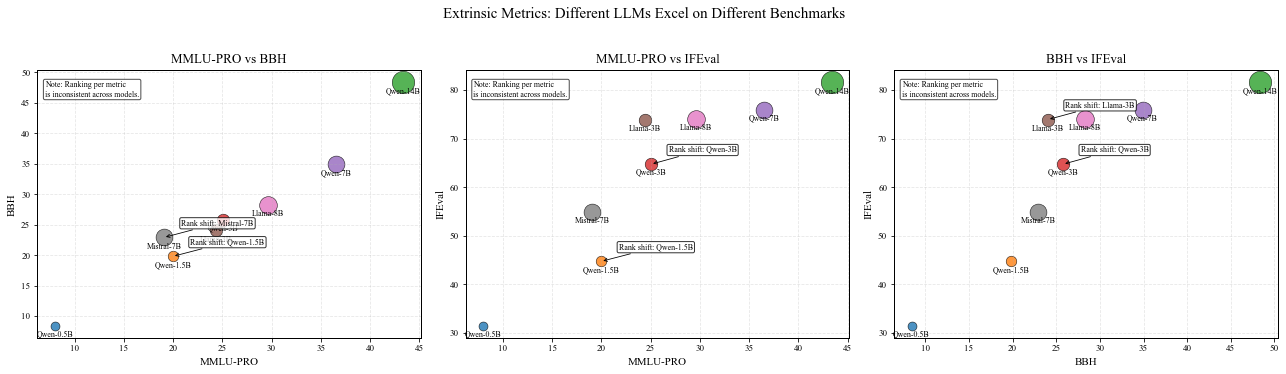

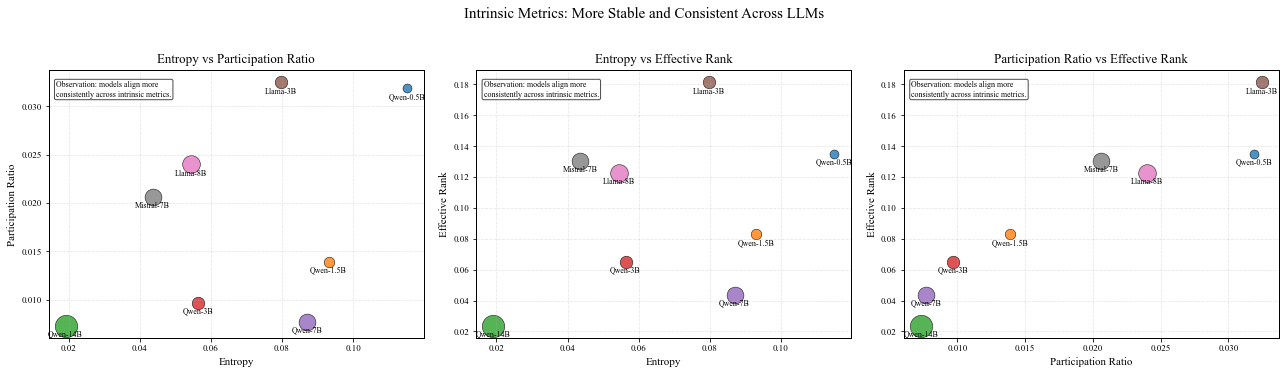

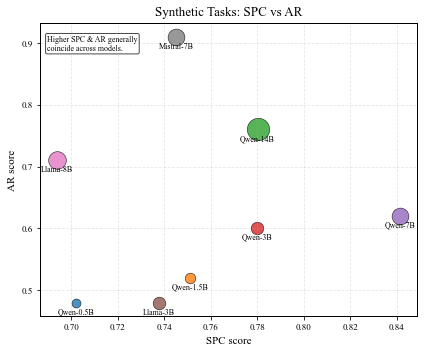

In [40]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

# =========================
# 1. Load data & utilities
# =========================

CSV_PATH = "final_data.csv"   # adjust if needed

df = pd.read_csv(CSV_PATH)

# Expecting columns:
# ['Model', 'IFEval', 'BBH', 'MMLU-PRO', 'Entropy',
#  'Participation Ratio', 'Effective Rank', 'SPC', 'AR']


def parse_model_size_b(name: str) -> float:
    """
    Parse model size in billions from a name like:
    'Qwen-0.5B', 'Llama-8B', 'Mistral-7B', etc.
    Returns 1.0 if no size is found.
    """
    m = re.search(r'(\d+(\.\d+)?)\s*B', name, re.IGNORECASE)
    if m:
        return float(m.group(1))
    return 1.0


# Add a column for model size in billions
df["ModelSizeB"] = df["Model"].apply(parse_model_size_b)

# Build a deterministic color map: one color per model
models = df["Model"].tolist()
n_models = len(models)
cmap = get_cmap("tab10") if n_models <= 10 else get_cmap("tab20")

model_to_color = {
    model: cmap(i % cmap.N) for i, model in enumerate(models)
}


def compute_point_sizes(sizes_b, min_size=80, max_size=500):
    """
    Map model sizes in billions to bubble sizes for scatter.
    """
    sizes_b = np.asarray(sizes_b, dtype=float)
    if sizes_b.max() == sizes_b.min():
        return np.full_like(sizes_b, (min_size + max_size) / 2.0)
    norm = (sizes_b - sizes_b.min()) / (sizes_b.max() - sizes_b.min())
    return min_size + norm * (max_size - min_size)


def scatter_with_labels(ax, df, x_col, y_col, title,
                        x_label=None, y_label=None,
                        annotate_rank_diff=False):
    """
    Scatter plot with:
      - one color per model
      - bubble size ~ model size (B)
      - model name under each point
      - optional annotation of models with largest rank disagreement
    """
    x = df[x_col].values
    y = df[y_col].values
    sizes = compute_point_sizes(df["ModelSizeB"].values)
    models = df["Model"].values

    # Plot points
    for xi, yi, s, m in zip(x, y, sizes, models):
        ax.scatter(xi, yi,
                   s=s,
                   color=model_to_color[m],
                   alpha=0.8,
                   edgecolor="black",
                   linewidth=0.6)

    # Add model names slightly below the point
    x_range = x.max() - x.min() if x.max() != x.min() else 1.0
    y_range = y.max() - y.min() if y.max() != y.min() else 1.0

    for xi, yi, m in zip(x, y, models):
        ax.text(
            xi,
            yi - 0.02 * y_range,
            m,
            ha="center",
            va="top",
            fontsize=8,
        )

    ax.set_title(title, fontsize=20, pad=8)
    ax.set_xlabel(x_label if x_label else x_col, fontsize=15)
    ax.set_ylabel(y_label if y_label else y_col, fontsize=15)

    ax.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(axis="both", labelsize=9)

    # Optional: annotate models with biggest rank disagreement
    if annotate_rank_diff:
        # ranks: higher value -> better rank (so use -series.argsort?)
        # We'll use descending ranks (1 = best).
        x_ranks = df[x_col].rank(ascending=False, method="average")
        y_ranks = df[y_col].rank(ascending=False, method="average")
        rank_diff = (x_ranks - y_ranks).abs()

        # Take up to 2 most disagreeing models
        num_annotate = min(2, len(df))
        idx_sorted = rank_diff.sort_values(ascending=False).index[:num_annotate]

        for idx in idx_sorted:
            row = df.loc[idx]
            xi, yi, m = row[x_col], row[y_col], row["Model"]
            dx = 0.05 * x_range
            dy = 0.05 * y_range
            ax.annotate(
                f"Rank shift: {m}",
                xy=(xi, yi),
                xytext=(xi + dx, yi + dy),
                arrowprops=dict(arrowstyle="->", linewidth=0.8),
                fontsize=8,
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
            )


# =========================
# 2. Plot 1: Extrinsic metrics
# =========================

def plot_extrinsic_metrics(df):
    """
    Show that extrinsic metrics are not robust:
    different LLMs can be strong on different tasks.
    We use 3 pairwise scatter plots among [MMLU-PRO, BBH, IFEval].
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    extrinsic_pairs = [
        ("MMLU-PRO", "BBH"),
        ("MMLU-PRO", "IFEval"),
        ("BBH", "IFEval"),
    ]
    titles = [
        "MMLU-PRO vs BBH",
        "MMLU-PRO vs IFEval",
        "BBH vs IFEval",
    ]

    for ax, (x_col, y_col), title in zip(axes, extrinsic_pairs, titles):
        scatter_with_labels(
            ax,
            df,
            x_col=x_col,
            y_col=y_col,
            title=title,
            annotate_rank_diff=True
        )
        # Add a general text annotation in axis coordinates
        ax.text(
            0.02,
            0.96,
            "Note: Ranking per metric\nis inconsistent across models.",
            transform=ax.transAxes,
            fontsize=8,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.suptitle(
        "Extrinsic Metrics: Different LLMs Excel on Different Benchmarks",
        fontsize=15,
        y=1.03,
    )
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "plot1_extrinsic_metrics.svg"), format="svg", bbox_inches="tight", dpi=300)


# =========================
# 3. Plot 2: Intrinsic metrics
# =========================

def plot_intrinsic_metrics(df):
    """
    Show that intrinsic metrics (Entropy, Participation Ratio,
    Effective Rank) produce more consistent LLM rankings.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    intrinsic_pairs = [
        ("Entropy", "Participation Ratio"),
        ("Entropy", "Effective Rank"),
        ("Participation Ratio", "Effective Rank"),
    ]
    titles = [
        "Entropy vs Participation Ratio",
        "Entropy vs Effective Rank",
        "Participation Ratio vs Effective Rank",
    ]

    for ax, (x_col, y_col), title in zip(axes, intrinsic_pairs, titles):
        scatter_with_labels(
            ax,
            df,
            x_col=x_col,
            y_col=y_col,
            title=title,
            annotate_rank_diff=False,  # we expect more consistency
        )
        ax.text(
            0.02,
            0.96,
            "Observation: models align more\nconsistently across intrinsic metrics.",
            transform=ax.transAxes,
            fontsize=8,
            va="top",
            ha="left",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
        )

    fig.suptitle(
        "Intrinsic Metrics: More Stable and Consistent Across LLMs",
        fontsize=15,
        y=1.03,
    )
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "plot2_intrinsic_metrics.svg"), format="svg", bbox_inches="tight", dpi=300)


# =========================
# 4. Plot 3: Synthetic tasks (SPC, AR)
# =========================

def plot_synthetic_tasks(df):
    """
    Show that synthetic tasks (SPC, AR) are also reliable for ranking LLMs.
    We plot SPC vs AR.
    """
    fig, ax = plt.subplots(figsize=(6, 5))

    scatter_with_labels(
        ax,
        df,
        x_col="SPC",
        y_col="AR",
        title="Synthetic Tasks: SPC vs AR",
        x_label="SPC score",
        y_label="AR score",
        annotate_rank_diff=False,
    )

    ax.text(
        0.02,
        0.96,
        "Higher SPC & AR generally\ncoincide across models.",
        transform=ax.transAxes,
        fontsize=8,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7),
    )

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "plot3_synthetic_tasks.svg"), format="svg", bbox_inches="tight", dpi=300)


# =========================
# 5. Run all plots
# =========================

if __name__ == "__main__":
    plot_extrinsic_metrics(df)
    plot_intrinsic_metrics(df)
    plot_synthetic_tasks(df)
    print("Saved SVGs: plot1_extrinsic_metrics.svg, plot2_intrinsic_metrics.svg, plot3_synthetic_tasks.svg")


Saved plot3_intrinsic_scores.svg

All SVG plots generated successfully.



/var/folders/pz/5lsvsk5s79q_8bbzj9jj5vv00000gn/T/ipykernel_93117/3298527122.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("tab10") if len(models) <= 10 else get_cmap("tab20")


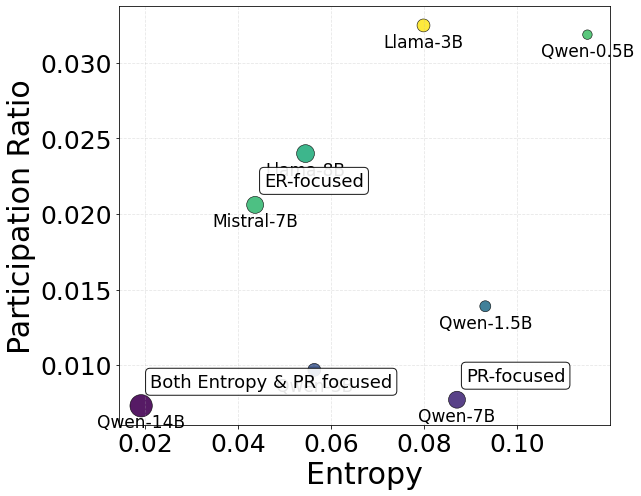

In [5]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.patches import Ellipse

# ============================================================
# 1. Load Data & Helpers
# ============================================================

CSV_PATH = "final_data.csv"
df = pd.read_csv(CSV_PATH)

def parse_model_size_b(name: str) -> float:
    """Extract size in billions from model name."""
    m = re.search(r'(\d+(\.\d+)?)\s*B', name, re.IGNORECASE)
    return float(m.group(1)) if m else 1.0

df["ModelSizeB"] = df["Model"].apply(parse_model_size_b)

models = df["Model"].tolist()
cmap = get_cmap("tab10") if len(models) <= 10 else get_cmap("tab20")
model_to_color = {m: cmap(i % cmap.N) for i, m in enumerate(models)}

def compute_point_sizes(sizes_b, min_size=90, max_size=500):
    sizes = np.array(sizes_b)
    if sizes.max() == sizes.min():
        return np.full_like(sizes, (min_size + max_size) / 2.0)
    norm = (sizes - sizes.min()) / (sizes.max() - sizes.min())
    return min_size + norm * (max_size - min_size)

def _find_index_by_substrings(df, substrings):
    mask = pd.Series([True] * len(df))
    for s in substrings:
        mask &= df["Model"].str.contains(s, case=False, na=False)
    idx = df[mask].index.tolist()
    return idx[0] if idx else None


# ============================================================
# 2. Scatter Utility
# ============================================================

def scatter_with_labels(ax, df, x_col, y_col, title, x_label=None, y_label=None):
    x = df[x_col].values
    y = df[y_col].values
    sizes = compute_point_sizes(df["ModelSizeB"].values)

    x_range = x.max() - x.min() if x.max() != x.min() else 1.0
    y_range = y.max() - y.min() if y.max() != y.min() else 1.0

    for xi, yi, s, m in zip(x, y, sizes, df["Model"]):
        ax.scatter(
            xi, yi,
            s=s,
            color=model_to_color[m],
            alpha=0.85,
            edgecolor="black",
            linewidth=0.6,
        )
        ax.text(
            xi,
            yi + 0.1 * y_range,
            m,
            ha="center",
            va="top",
            fontsize=17,
        )

    ax.set_title(title, fontsize=30)
    ax.set_xlabel(x_label or x_col, fontsize=30)
    ax.set_ylabel(y_label or y_col, fontsize=30)
    ax.grid(True, linestyle="--", alpha=0.3)
    ax.tick_params(axis="both", labelsize=25)


# ============================================================
# 3. PLOT 1 — Extrinsic metrics inconsistency
# ============================================================

def plot_extrinsic_inconsistent(df):
    x_col = "MMLU-PRO"
    y_col = "IFEval"

    fig, ax = plt.subplots(figsize=(9, 7))

    # Base scatter
    scatter_with_labels(
        ax,
        df,
        x_col=x_col,
        y_col=y_col,
        title="Extrinsic Benchmarks Give Inconsistent LLM Rankings",
        x_label="MMLU-PRO (%)",
        y_label="IFEval (%)",
    )

    x = df[x_col].values
    y = df[y_col].values
    x_range = x.max() - x.min() or 1.0
    y_range = y.max() - y.min() or 1.0

    # Identify key models
    idx_llama3 = _find_index_by_substrings(df, ["llama", "3b"])
    idx_qwen3  = _find_index_by_substrings(df, ["qwen", "3b"])
    idx_llama8 = _find_index_by_substrings(df, ["llama", "8b"])

    # ----------------------------------------------------------
    # Annotation 1 — Llama 3B better in IFEval, Qwen 3B better in MMLU
    #   → arrow points to Qwen 3B
    # ----------------------------------------------------------
    if idx_llama3 is not None and idx_qwen3 is not None:
        p_l3 = df.loc[idx_llama3]
        p_q3 = df.loc[idx_qwen3]

        x_q3, y_q3 = p_q3[x_col], p_q3[y_col]

        # Place text slightly away from Qwen 3B
        text_x = x_q3 - 0.45 * x_range
        text_y = y_q3 + 0.05 * y_range

        ax.annotate(
            "Llama 3B better in IFEval,\n"
            "but Qwen 3B better in MMLU",
            xy=(x_q3, y_q3),
            xytext=(text_x, text_y),
            #arrowprops=dict(arrowstyle="->", linewidth=0.8),
            fontsize=18,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.5),
        )

    # ----------------------------------------------------------
    # Annotation 2 — Llama 3B & 8B similar on IFEval, very different on MMLU
    #   → arrow points to Llama 3B
    # ----------------------------------------------------------
    if idx_llama3 is not None and idx_llama8 is not None:
        p_l3 = df.loc[idx_llama3]
        p_l8 = df.loc[idx_llama8]

        x_l3, y_l3 = p_l3[x_col], p_l3[y_col]

        text_x = x_l3 - 0.3 * x_range
        text_y = y_l3 + 0.12 * y_range

        ax.annotate(
            "Llama 3B and Llama 8B\n"
            "similar on IFEval but\n"
            "different in MMLU",
            xy=(x_l3, y_l3),
            xytext=(text_x, text_y),
            #arrowprops=dict(arrowstyle="->", linewidth=0.8),
            fontsize=18,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.9),
        )

    # ----------------------------------------------------------
    # Annotation 3 — Elliptical shaded region around top-right cluster
    # ----------------------------------------------------------
    x_norm = (x - x.min()) / (x_range if x_range else 1.0)
    y_norm = (y - y.min()) / (y_range if y_range else 1.0)
    score = x_norm + y_norm
    top4_idx = np.argsort(score)[-4:]

    # Cluster center and radii
    cx = x[top4_idx].mean()
    cy = y[top4_idx].mean()
    rx = (x[top4_idx].max() - x[top4_idx].min()) / 2.0 + 0.03 * x_range
    ry = (y[top4_idx].max() - y[top4_idx].min()) / 2.0 + 0.03 * y_range

    ellipse = Ellipse(
        (cx, cy),
        width=3 * rx,
        height=3 * ry,
        angle=0,
        facecolor="red",
        edgecolor="red",
        alpha=0.12,
        linewidth=1.0,
    )
    ax.add_patch(ellipse)

    # Annotation pointing to the ellipse
    ann_x = cx + 0.0 * x_range
    ann_y = cy - 0.2 * y_range

    #ax.annotate(
    #    "Highly colluded & non-separable",
    #    xy=(cx, cy),
    #    xytext=(ann_x, ann_y),
    #    fontsize=18,
    #    bbox=dict(boxstyle="round,pad=0.28", fc="white", alpha=0.9),
    #)

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "plot1_extrinsic_inconsistent.svg"), dpi=300, bbox_inches="tight")
    print("Saved plot1_extrinsic_inconsistent.svg")


# ============================================================
# 4. PLOT 2 — Synthetic tasks are reliable
# ============================================================

def annotate_practitioner_guidance(ax, df, x_col="SPC", y_col="AR"):
    x = df[x_col]
    y = df[y_col]
    x_range = x.max() - x.min() or 1.0
    y_range = y.max() - y.min() or 1.0

    idx_best_entropy = df["Entropy"].idxmin()
    idx_best_pr = df["Participation Ratio"].idxmax()
    idx_best_er = df["Effective Rank"].idxmax()

    spc_rank = df["SPC"].rank(ascending=False)
    ar_rank = df["AR"].rank(ascending=False)
    balanced = (spc_rank + ar_rank).idxmin()

    labels = [
        ("Balanced choice", 2),
        ("Entropy-focused", 7),
        ("PR-focused", 4),
    ]

    for label, idx in labels:
        row = df.loc[idx]
        xi, yi = row[x_col], row[y_col]
        dx = -0.2 * x_range
        dy = -0.15 * y_range

        if label == "Balanced choice":
            txt = f"{row['Model']}: balanced\nHigh SPC & AR"
        elif label == "Entropy-focused":
            txt = f"{row['Model']}: lowest entropy\nHighest AR"
        elif label == "PR-focused":
            txt = f"{row['Model']}: highest PR\nHighest SPC"
        else:  # ER-focused
            txt = f"{row['Model']}: highest ER\nHigh-dimensional representations"

        ax.annotate(
            txt,
            xy=(xi, yi),
            xytext=(xi + dx, yi + dy),
            #arrowprops=dict(arrowstyle="->", linewidth=0.8),
            fontsize=18,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.9),
        )


def plot_synthetic_intrinsic_reliable(df):
    fig, ax = plt.subplots(figsize=(9, 7))

    scatter_with_labels(
        ax,
        df,
        x_col="SPC",
        y_col="AR",
        title="Synthetic Tasks Are More Reliable for LLM Ranking",
        x_label="SPC Score",
        y_label="AR Score",
    )

    annotate_practitioner_guidance(ax, df)

    #ax.text(
    #    0.02,
    #    0.97,
    #    "Synthetic tasks align well with intrinsic metrics\n"
    #    "(entropy, PR, effective rank), giving a stable ranking.",
    #    transform=ax.transAxes,
    #    fontsize=9,
    #    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9),
    #)

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "plot2_synthetic_intrinsic_reliable.svg"), dpi=300, bbox_inches="tight")
    print("Saved plot2_synthetic_intrinsic_reliable.svg")


# ============================================================
# 5. PLOT 3 — Intrinsic metrics visualization
# ============================================================

def plot_intrinsic_scores(df):
    x_col = "Entropy"
    y_col = "Participation Ratio"
    c_col = "Effective Rank"

    x = df[x_col].values
    y = df[y_col].values
    c = df[c_col].values
    sizes = compute_point_sizes(df["ModelSizeB"].values)

    x_range = x.max() - x.min() or 1.0
    y_range = y.max() - y.min() or 1.0

    fig, ax = plt.subplots(figsize=(9, 7))

    # Normalize ER for color
    c_norm = (c - c.min()) / (c.max() - c.min() or 1.0)

    scatter = ax.scatter(
        x,
        y,
        s=sizes,
        c=c_norm,
        cmap="viridis",
        edgecolor="black",
        linewidth=0.6,
        alpha=0.9,
    )

    for xi, yi, m in zip(x, y, df["Model"]):
        ax.text(xi, yi - 0.02 * y_range, m, ha="center", va="top", fontsize=17)

    #cbar = fig.colorbar(scatter, ax=ax)
    #cbar.set_label("Effective Rank (normalized)")

    ax.set_xlabel("Entropy", fontsize=30)
    ax.set_ylabel("Participation Ratio", fontsize=30)
    #ax.set_title("Intrinsic Metrics for Model Selection", fontsize=30)
    ax.tick_params(axis="both", labelsize=25)

    ax.grid(True, linestyle="--", alpha=0.3)

    # Identify intrinsic champions
    idx_ent = df["Entropy"].idxmin()
    idx_pr = df["Participation Ratio"].idxmax()
    idx_er = df["Effective Rank"].idxmax()

    ent_z = (df["Entropy"] - df["Entropy"].mean()) / (df["Entropy"].std() + 1e-8)
    pr_z = (df["Participation Ratio"] - df["Participation Ratio"].mean()) / (df["Participation Ratio"].std() + 1e-8)
    er_z = (df["Effective Rank"] - df["Effective Rank"].mean()) / (df["Effective Rank"].std() + 1e-8)
    balanced = (-ent_z + pr_z + er_z).idxmax()

    for label, idx in [
        ("Both Entropy & PR focused", idx_ent),
        ("PR-focused", 4),
        ("ER-focused", 7),
        #("Balanced choice", balanced),
    ]:
        row = df.loc[idx]
        xi, yi = row[x_col], row[y_col]

        ax.annotate(
            f"{label}",
            xy=(xi, yi),
            xytext=(xi + 0.02 * x_range, yi + 0.05 * y_range),
            #arrowprops=dict(arrowstyle="->", linewidth=0.8),
            fontsize=18,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.9),
        )

    #ax.text(
    #    0.02,
    #    0.97,
    #    "Intrinsic view for practitioners:\n"
    #    "- Move left for lower entropy (stable behavior).\n"
    #    "- Move up for higher PR (richer usage).\n"
    #    "- Prefer darker points for higher effective rank.",
    #    transform=ax.transAxes,
    #    fontsize=9,
    #    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.9),
    #)

    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "plot3_intrinsic_scores.svg"), dpi=300, bbox_inches="tight")
    print("Saved plot3_intrinsic_scores.svg")


# ============================================================
# 6. Run All Plots
# ============================================================

if __name__ == "__main__":
    #plot_extrinsic_inconsistent(df)
    #plot_synthetic_intrinsic_reliable(df)
    plot_intrinsic_scores(df)
    print("\nAll SVG plots generated successfully.\n")


In [76]:
df

,Model,IFEval,BBH,MMLU-PRO,Entropy,Participation Ratio,Effective Rank,SPC,AR,ModelSizeB
0,Qwen-0.5B,31.529121,8.434864,7.995346,0.115086,0.031864,0.135234,0.702048,0.48,0.5
1,Qwen-1.5B,44.755693,19.809787,19.991135,0.093120,0.013899,0.082870,0.750969,0.52,1.5
2,Qwen-14B,81.577769,48.360707,43.382462,0.019099,0.007315,0.023769,0.780208,0.76,14.0
3,Qwen-3B,64.749199,25.801394,25.051714,0.056345,0.009691,0.064886,0.779782,0.60,3.0
4,Qwen-7B,75.852516,34.892117,36.521129,0.087032,0.007716,0.043613,0.841574,0.62,7.0
5,Llama-3B,73.931613,24.059186,24.386820,0.079830,0.032475,0.181351,0.737619,0.48,3.0
6,Llama-8B,74.083986,28.244950,29.604388,0.054458,0.023997,0.122512,0.693714,0.71,8.0
7,Mistral-7B,54.962278,22.910602,19.076906,0.043618,0.020603,0.130520,0.745238,0.91,7.0
